# Module 7 · Take-Home Lab — Context Window Management & Compaction
## Thirty turns, a context window that fills up, and three fixes measured at each step

*Created by Prashant Sahu · [LinkedIn](https://www.linkedin.com/in/prashantksahu/)*

---

### Where this sits

This take-home returns to the **ShopSmart** support agent from Lab 7.1 and asks what happens when its conversations get **long**:

| | Lab | What it added |
|---|---|---|
| | **Lab 7.1** | routing — classify the query, dispatch to a handler |
| | **Lab 7.2** | HITL + checkpointed memory |
| **you are here** | take-home | the agent survives a **long** conversation |
| next | take-home | reusable skills — what is allowed *into* the window |

The agent below is a deliberately light stand-in for a full support graph — one prompt, one model call per turn — so the context mechanics stay visible instead of being buried in a `StateGraph`. Everything you measure here applies unchanged to a real one.

---

### How to work through this lab

| | Sections | Roughly |
|---|---|---|
| **Core** | 1 – 7 — the problem, the three fixes, the token budget, and the before/after dashboard | ~90 min |
| **Deep dive** | 8 – 11 — the middleware that does this for you, provider-specific token counting, the memory-framework landscape, and the production checklist | at your own pace |

**A warning before you run anything:** the core makes roughly **150 model calls** across five 30-turn runs plus judging. Budget a few US cents and a few minutes per run — the notebook prints the exact figure for every configuration in section 7.

Take the ShopSmart support agent from Lab 7.1, give it **real tools that return real JSON**, and run it for **30 turns**. Measure what that costs, apply **three progressive fixes** — history compaction, tool-result clearing and just-in-time retrieval — and measure what each one saves *and what each one costs you*. The interesting result is not that the fixes work. It is that one of them quietly loses the customer's own words while doing so.

## Business Scenario: ShopSmart — The Long Conversation Problem

ShopSmart's AI support agent handles multi-turn customer conversations. As the product scales:

1. **Every turn pays for every previous turn.** The API is stateless, so turn 30 re-sends
   turns 1 through 29 along with it. The window grows in a straight line; the bill grows faster
   than that. You will measure both.

2. **Tool results are what fill the window.** An order lookup comes back as a complete record —
   line items, every payment attempt, the full carrier scan history. The agent reads it once,
   answers, and then carries it for the rest of the conversation.

3. **The policy document is loaded whether it is wanted or not.** All seven sections go into
   the system prompt on every turn, including the six the customer never asks about — and on
   the eleven turns that are pure product questions, all seven are dead weight.

4. **Every fix is a trade, and the trade is the lesson.** Each of the three techniques below
   buys tokens back. One of them also loses facts the customer gave you — and it is the one
   most teams reach for first.

**How this is measured.** Token counts come from the provider's own `usage_metadata`, not an
estimate. Whether the agent still remembers is measured by **deterministic recall probes** —
substring checks for facts the customer stated that appear in no tool result — not by asking a
model whether an answer looked good. Costs are priced in US dollars from an editable price
table, and section 1 prints a join check proving the probe facts exist nowhere in the data.

> **A note on what you will not see.** This conversation does not overflow a 128K window, and
> the lab does not pretend otherwise. At thirty turns of customer support the thing that bites
> first is the invoice, not the limit. Section 6 shows where the limit does start to matter.

> 🏠 **Take-home reference lab.** Not run in the workshop sessions — work through it afterwards at your own pace. Its API keys are yours to create (see the workshop's `README.md`).

In [1]:
# 📦 Packages this notebook needs. On the workshop VM they are pre-installed from
# the workshop's requirements.txt, so the install line below stays commented out.
# Running somewhere else (Colab, your own laptop)? Uncomment it and run this cell once.
# !pip install -qU langchain langchain-openai langchain-anthropic tiktoken matplotlib python-dotenv

from importlib.metadata import PackageNotFoundError, version

NOTEBOOK_PACKAGES = [
    "langchain",
    "langchain-openai",
    "langchain-anthropic",
    "tiktoken",
    "matplotlib",
    "python-dotenv",
]
for package_name in NOTEBOOK_PACKAGES:
    try:
        print(f"{package_name:<26} {version(package_name)}")
    except PackageNotFoundError:
        print(f"{package_name:<26} NOT INSTALLED — uncomment the !pip line above")

langchain                  1.4.3
langchain-openai           1.6.6
langchain-anthropic        1.7.5
tiktoken                   0.14.0
matplotlib                 3.11.2
python-dotenv              1.2.3


In [2]:
import os

# Where to create each key. The trainer supplies OPENAI_API_KEY on the workshop VM;
# you create any other key yourself and add it to the workshop's .env file as KEY_NAME=value.
KEY_SIGNUP_PAGES = {
    "OPENAI_API_KEY": "supplied on the workshop VM (elsewhere: https://platform.openai.com/api-keys)",
    "TAVILY_API_KEY": "https://app.tavily.com (free tier)",
    "GROQ_API_KEY": "https://console.groq.com/keys (free tier)",
    "WEATHER_API_KEY": "https://www.weatherapi.com/signup.aspx (free tier)",
    "LANGSMITH_API_KEY": "https://smith.langchain.com -> Settings -> API Keys (free tier)",
    "ANTHROPIC_API_KEY": "https://console.anthropic.com/settings/keys",
    "GEMINI_API_KEY": "https://aistudio.google.com/app/apikey",
}


def load_keys(required):
    """Load API keys from Colab Secrets (on Colab) or a local .env file (elsewhere).

    Prints one line per key, then stops with instructions if a required key is missing.

    Args:
        required: the environment-variable names this lab needs.
    """
    try:
        from google.colab import userdata          # running on Google Colab
        for key_name in required:
            try:
                os.environ[key_name] = userdata.get(key_name)
            except Exception:
                pass                                 # not set in Colab Secrets
        source = "Colab Secrets"
    except ImportError:                              # the workshop VM, or any local machine
        from dotenv import find_dotenv, load_dotenv
        load_dotenv(find_dotenv(usecwd=True))        # searches upward for the workshop's .env file
        source = ".env / environment"
    print(f"\U0001F511 Key source: {source}")
    for key_name in required:
        print(f"   {key_name:<22} {'✅' if os.environ.get(key_name) else '❌ MISSING'}")
    missing_keys = [key_name for key_name in required if not os.environ.get(key_name)]
    if missing_keys:
        instructions = "\n".join(
            f"  {key_name}: {KEY_SIGNUP_PAGES.get(key_name, 'see README.md in the workshop folder')}"
            for key_name in missing_keys)
        raise RuntimeError(
            "This lab needs API keys that are not set yet. Create each one, add it to\n"
            "the workshop's .env file as KEY_NAME=value, then re-run this cell:\n" + instructions)


# Two providers on purpose: the ShopSmart agent runs on OpenAI and the quality judge runs
# on Anthropic. A judge that shares a model family with the system it grades inflates every
# score it produces — §5 of the Reusable Skills take-home covers why; this lab's quality curve depends on it.
load_keys(["OPENAI_API_KEY", "ANTHROPIC_API_KEY"])

# --- Imports ---
import copy
import datetime
import json

import matplotlib.pyplot as plt
import tiktoken
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

# --- Models ---
# chat_model  = the ShopSmart agent under test
# judge_model = the quality grader, from a DIFFERENT model family on purpose
chat_model = ChatOpenAI(model="gpt-4.1-mini", temperature=0.3)
judge_model = ChatAnthropic(model="claude-haiku-4-5", temperature=0)

print("Imports loaded.")
print("  ShopSmart agent : gpt-4.1-mini (temp=0.3)")
print("  Quality judge   : claude-haiku-4-5 (temp=0) — different family, on purpose")

🔑 Key source: .env / environment
   OPENAI_API_KEY         ✅
   ANTHROPIC_API_KEY      ✅


Imports loaded.
  ShopSmart agent : gpt-4.1-mini (temp=0.3)
  Quality judge   : claude-haiku-4-5 (temp=0) — different family, on purpose


## 1. The ShopSmart Data — the Real Files, Not a Copy of Them

"Carried forward" has meant different things in different labs. Here it means one specific
thing: the next cell opens the **five pre-provided ShopSmart files** in `ShopSmart Data/`, byte for byte.
Nothing is retyped and nothing is trimmed.

| File | What it holds | Why this lab needs it |
|---|---|---|
| `customers.json` | 10 customers with tiers | the agent greets a real customer, and joins to their orders |
| `orders.json` | 100 orders, line items, USD totals, ISO dates | the tool payloads that fill the window |
| `products.json` | 20 products with specs and FAQ | what a catalogue search returns |
| `tickets.json` | 100 tickets, **labelled** by category | not used here — an evaluation suite would score against these labels |
| `policies.md` | the support policy document | the system prompt, and the corpus for just-in-time retrieval in section 5 |

> **Why this matters more than it looks.** An earlier version of this lab re-declared a
> five-order dictionary inline. It looked like the same scenario, but the join keys were gone:
> no `customer_id` on an order, no `product_id` on a line item. That is fine until you want to
> ask "what else has this customer ordered?" — and it is exactly the question a support agent
> asks. The loader below restores those keys, and prints a join check to prove they resolve.

Section 5 needs a corpus with *parts*, so the second cell splits `policies.md` on its own
headings rather than inventing a taxonomy for it.

*The five files below ship with this lab, in `ShopSmart Data/`. Nothing here is retyped.*

In [3]:
# --- ShopSmart data: the pre-provided files, loaded as they ship ---
# These are the five ShopSmart files, byte for byte. Nothing is retyped
# and nothing is trimmed, so the join keys survive: a ticket carries a customer_id, a customer
# owns orders, an order references products. Everything below depends on that.

def resolve_data_file(file_name):
    """Find one pre-provided ShopSmart data file across the likely locations.

    Colab users upload the "ShopSmart Data" folder next to the notebook; local users may run
    from the module directory or one level above it. Try each in turn.

    Args:
        file_name: a file inside the data folder, e.g. "orders.json".

    Returns:
        The first path that exists.

    Raises:
        FileNotFoundError: if none of the candidate locations contain it.
    """
    candidate_folders = (
        "ShopSmart Data/",
        "",
        "../ShopSmart Data/",
        "../",
    )
    for base_folder in candidate_folders:
        candidate_path = base_folder + file_name
        if os.path.exists(candidate_path):
            return candidate_path
    raise FileNotFoundError(
        f"Could not find '{file_name}'. On Colab, upload the 'ShopSmart Data' folder "
        f"next to this notebook."
    )


def load_json_data_file(file_name):
    """Load one pre-provided JSON data file and return its parsed contents."""
    with open(resolve_data_file(file_name), encoding="utf-8") as data_file:
        return json.load(data_file)


customers_raw = load_json_data_file("customers.json")
orders_raw = load_json_data_file("orders.json")
products_raw = load_json_data_file("products.json")
TICKETS = load_json_data_file("tickets.json")

with open(resolve_data_file("policies.md"), encoding="utf-8") as policies_file:
    POLICIES = policies_file.read()

# Index by primary key for O(1) lookup — one dictionary per file.
CUSTOMERS_DATABASE = {customer["customer_id"]: customer for customer in customers_raw}
ORDERS_DATABASE = {order["order_id"]: order for order in orders_raw}
PRODUCTS_DATABASE = {product["product_id"]: product for product in products_raw}

# Reverse index: which orders belong to which customer. This is the join an earlier
# inline rewrite of this lab deleted, and the reason a support agent can answer "what else have I ordered?".
CUSTOMER_ORDERS = {}
for order in orders_raw:
    CUSTOMER_ORDERS.setdefault(order["customer_id"], []).append(order)

print(f"ShopSmart data loaded from the pre-provided files:")
print(f"  customers : {len(CUSTOMERS_DATABASE):>4}   tiers {sorted({customer_record['tier'] for customer_record in customers_raw})}")
print(f"  orders    : {len(ORDERS_DATABASE):>4}   statuses {sorted({order_record['status'] for order_record in orders_raw})}")
print(f"  products  : {len(PRODUCTS_DATABASE):>4}   categories {sorted({product_record['category'] for product_record in products_raw})}")
print(f"  tickets   : {len(TICKETS):>4}   categories {sorted({ticket_record['category'] for ticket_record in TICKETS})}")
print(f"  policies  : {len(POLICIES):>4} characters")
print()
print(f"  join check: {len(CUSTOMER_ORDERS)} of {len(CUSTOMERS_DATABASE)} customers have orders; "
      f"every order's customer_id resolves = "
      f"{all(order['customer_id'] in CUSTOMERS_DATABASE for order in orders_raw)}")


ShopSmart data loaded from the pre-provided files:
  customers :   10   tiers ['bronze', 'platinum', 'silver']
  orders    :  100   statuses ['cancelled', 'delivered', 'in_transit', 'processing']
  products  :   20   categories ['Books', 'Clothing', 'Electronics', 'Home & Garden', 'Sports']
  tickets   :  100   categories ['billing', 'escalation', 'order_status', 'product_inquiry', 'returns', 'technical']
  policies  : 2974 characters

  join check: 10 of 10 customers have orders; every order's customer_id resolves = True


In [4]:
# --- Split the real policy document into retrievable sections ---
# Just-in-time retrieval needs a corpus with parts. Rather than invent one, we split ShopSmart's
# actual policies.md on its own top-level headings. The section names below are read OUT of the
# document, never hard-coded, so if the policy file changes this keeps working.

def split_policy_document(policy_markdown):
    """Split a markdown policy document into {section_name: section_text} on its "## " headings.

    Args:
        policy_markdown: the full contents of policies.md.

    Returns:
        An ordered dict-like mapping of lower-cased section key to the section's full text,
        heading included.
    """
    sections = {}
    current_key = None
    current_lines = []
    for line in policy_markdown.splitlines():
        if line.startswith("## "):
            if current_key is not None:
                sections[current_key] = "\n".join(current_lines).strip()
            heading = line[3:].strip()
            current_key = heading.lower().replace(" & ", " ").replace(" ", "_")
            current_lines = [line]
        elif current_key is not None:
            current_lines.append(line)
    if current_key is not None:
        sections[current_key] = "\n".join(current_lines).strip()
    return sections


POLICY_SECTIONS = split_policy_document(POLICIES)
ALL_POLICY_TEXT = "\n\n".join(POLICY_SECTIONS.values())

print(f"policies.md split into {len(POLICY_SECTIONS)} sections:")
for section_key, section_text in POLICY_SECTIONS.items():
    print(f"  {section_key:<22} {len(section_text):>5} chars")
print(f"\n  all sections combined: {len(ALL_POLICY_TEXT)} chars")


policies.md split into 7 sections:
  return_refund_policy     711 chars
  shipping_policy          277 chars
  billing_payment_policy   374 chars
  order_modification_cancellation   384 chars
  customer_service_escalation_criteria   396 chars
  technical_support        408 chars
  special_circumstances    372 chars

  all sections combined: 2934 chars


In [5]:
# --- The records the tools hand back ---
# Section 1 loaded five flat files. This cell builds what an ORDER-MANAGEMENT API actually
# returns for one order: the order joined to its customer, every line item joined to its full
# product record, the charges, the payment attempts and the status history.
#
# Notice where the bulk comes from. Nothing here is padding and nothing is invented — it is the
# SAME data, expanded across the join keys the ShopSmart files carry. That is exactly why a
# tool-calling agent fills a context window an order of magnitude faster than a chat-only one:
# real APIs expand relations, and every expansion lands in the window and stays there.
#
# One honest exception, called out rather than hidden: carrier SCAN EVENTS are not in the
# dataset. orders.json gives us a tracking number and two dates; the ten scans between them are
# derived from those dates below. Everything else on this page is read from the files.

PRODUCTS_BY_NAME = {product["name"]: product for product in products_raw}

# A shipment passes through these stages between dispatch and delivery. US network, because
# that is the locale the ShopSmart data is written in.
TRACKING_STAGES = [
    ("Order placed", "Columbus OH Fulfillment Center", "Payment authorized"),
    ("Picked from shelf", "Columbus OH Fulfillment Center", "Picker PKR-2291, tote T-8841"),
    ("Quality check passed", "Columbus OH QC Lane 3", "Seal intact, serial verified"),
    ("Packed", "Columbus OH Pack Station 9", "Box size M"),
    ("Handed to carrier", "Columbus OH Carrier Hub", "Manifest MFT-33120"),
    ("Departed origin facility", "Columbus OH Sort Facility", "Trailer 55-DQ-2210"),
    ("In transit", "Harrisburg PA Regional Hub", "Linehaul 7729"),
    ("Arrived at destination facility", "Newark NJ Delivery Station", "Sort code NWK-E-04"),
    ("Loaded for delivery", "Newark NJ Delivery Station", "Route R-22, bag BG-7741"),
    ("Out for delivery", "Newark NJ Delivery Station", "Driver DRV-4417, route R-22"),
]


def spread_dates_across_stages(start_iso_date, end_iso_date, stage_count):
    """Return `stage_count` ISO timestamps spaced evenly between two ISO timestamps.

    Args:
        start_iso_date: the order's own order_date.
        end_iso_date: the order's own estimated_delivery.
        stage_count: how many timestamps to produce.

    Returns:
        A list of ISO-8601 strings, ascending.
    """
    start_moment = datetime.datetime.fromisoformat(start_iso_date)
    end_moment = datetime.datetime.fromisoformat(end_iso_date)
    step = (end_moment - start_moment) / max(stage_count - 1, 1)
    return [(start_moment + step * index).isoformat(timespec="seconds")
            for index in range(stage_count)]


def build_order_record(order_id):
    """Return one complete order record, the way an order-management API returns it.

    Joins the order to its customer and each line item to its full product record, then adds
    the charges, payments and status history a support agent would need.

    Args:
        order_id: An order identifier present in ORDERS_DATABASE, e.g. "ORD-00001".

    Returns:
        A dict carrying the expanded order.
    """
    order = ORDERS_DATABASE[order_id]
    customer = CUSTOMERS_DATABASE[order["customer_id"]]

    line_items = []
    for line_number, item in enumerate(order["items"], start=1):
        product = PRODUCTS_BY_NAME[item["name"]]
        line_items.append({
            "line_number": line_number,
            "product_id": product["product_id"],
            "name": item["name"],
            "category": product["category"],
            "quantity": item["quantity"],
            "unit_price_usd": item["price"],
            "line_total_usd": round(item["price"] * item["quantity"], 2),
            "stock_status": product["stock_status"],
            "specifications": product["specs"],
            "product_faq": product["faq"],
            "return_window_days": 30,
        })

    subtotal = round(sum(line["line_total_usd"] for line in line_items), 2)
    return {
        "order_id": order["order_id"],
        "order_date": order["order_date"],
        "status": order["status"],
        "customer": {
            "customer_id": customer["customer_id"], "name": customer["name"],
            "email": customer["email"], "phone": customer["phone"], "tier": customer["tier"],
            "join_date": customer["join_date"],
            "past_tickets_count": customer["past_tickets_count"],
            "last_contact_date": customer["last_contact_date"],
            "total_orders_on_file": len(CUSTOMER_ORDERS.get(customer["customer_id"], [])),
        },
        "line_items": line_items,
        "charges": {
            "subtotal_usd": subtotal,
            "shipping_usd": 0.0 if subtotal >= 50 else 5.99,
            "order_total_usd": order["total"],
        },
        "payments": [{
            "payment_id": f"PAY-{order['order_id'][-5:]}",
            "method": "Credit Card", "network": "VISA",
            "last4": customer["phone"][-4:],
            "amount_usd": order["total"],
            "status": "captured",
            "authorized_at": order["order_date"],
        }],
        "status_history": [
            {"status": "created", "at": order["order_date"]},
            {"status": "payment_captured", "at": order["order_date"]},
            {"status": order["status"], "at": order["estimated_delivery"]},
        ],
        "tracking_number": order["tracking_number"],
        "estimated_delivery": order["estimated_delivery"],
    }


def build_shipment_record(order_id):
    """Return the carrier tracking record for one order.

    The carrier and the tracking number come from orders.json. The individual scan events are
    NOT in the dataset — they are derived from the order's own order_date and estimated_delivery
    so the timeline is consistent with the record it belongs to.

    Args:
        order_id: An order identifier present in ORDERS_DATABASE.

    Returns:
        A dict with the carrier, every tracking scan, and the delivery status.
    """
    order = ORDERS_DATABASE[order_id]
    customer = CUSTOMERS_DATABASE[order["customer_id"]]

    if not order["tracking_number"]:
        return {"order_id": order_id, "status": order["status"],
                "tracking_number": None,
                "message": "No tracking number has been assigned to this order yet.",
                "estimated_delivery": order["estimated_delivery"]}

    scan_timestamps = spread_dates_across_stages(
        order["order_date"], order["estimated_delivery"], len(TRACKING_STAGES))

    return {
        "order_id": order_id,
        "shipment_id": f"SHP-{order_id[-5:]}",
        "carrier": {"name": "ShopSmart Logistics", "tracking_number": order["tracking_number"],
                    "service_level": "Standard Ground", "support_phone": "1-800-555-0142"},
        "order_status": order["status"],
        "estimated_delivery": order["estimated_delivery"],
        "tracking_events": [
            {"sequence": index + 1, "stage": stage, "location": location, "note": note,
             "timestamp": scan_timestamps[index], "scan_type": "AUTO",
             "operator_id": f"OPS-{4400 + index}"}
            for index, (stage, location, note) in enumerate(TRACKING_STAGES)
        ],
        "recipient": {"customer_id": customer["customer_id"], "tier": customer["tier"]},
        "exceptions": [], "reattempt_count": 0, "signature_required": True,
    }


# The catalogue the product-search tool reads: the 20 real products, grouped by their own
# category field. No retyping — this is products.json, indexed a second way.
PRODUCT_CATALOGUE = {}
for product in products_raw:
    PRODUCT_CATALOGUE.setdefault(product["category"], []).append(product)

print(f"Record builders ready over {len(ORDERS_DATABASE)} orders and {len(PRODUCTS_DATABASE)} products.")
print(f"Catalogue categories: {sorted(PRODUCT_CATALOGUE)}")
print()
example_record = build_order_record("ORD-00088")
print(f"One expanded order (ORD-00088) joins {len(example_record['line_items'])} line items "
      f"to their product records and 1 customer record.")
print(f"Flat record in orders.json : {len(json.dumps(ORDERS_DATABASE['ORD-00088'])):>6,} characters")
print(f"Expanded, as the API returns it: {len(json.dumps(example_record)):>6,} characters")

Record builders ready over 100 orders and 20 products.
Catalogue categories: ['Books', 'Clothing', 'Electronics', 'Home & Garden', 'Sports']

One expanded order (ORD-00088) joins 3 line items to their product records and 1 customer record.
Flat record in orders.json :    489 characters
Expanded, as the API returns it:  2,323 characters


In [6]:
# --- Token counting, and an honest ledger ---
# Two different measurements, and the difference between them is the point of this lab:
#   * count_message_tokens() = how big the WINDOW is right now (what you are close to filling).
#   * RunLedger             = how many tokens you actually PAID for across the conversation,
#                             taken from the provider's own usage_metadata rather than estimated.
encoding = tiktoken.encoding_for_model("gpt-4o")

# List prices in USD per million tokens. Verify these against current pricing before you quote
# a number to anyone — they move, and the conclusion of this lab is a cost conclusion.
PRICE_PER_MILLION = {
    "gpt-4.1-mini": {"input": 0.40, "output": 1.60},
    "claude-haiku-4-5": {"input": 1.00, "output": 5.00},
}


def count_tokens(text):
    """Count tokens in a string using tiktoken."""
    return len(encoding.encode(text))


def count_message_tokens(messages):
    """Count the tokens a list of LangChain messages occupies in the context window.

    Args:
        messages: The running conversation, including tool calls and their results.

    Returns:
        Total tokens, counting each message's content, its tool-call arguments, and a small
        per-message overhead.
    """
    token_total = 0
    for message in messages:
        token_total += count_tokens(str(message.content)) + 4
        for tool_call in getattr(message, "tool_calls", None) or []:
            token_total += count_tokens(json.dumps(tool_call.get("args", {})))
    return token_total


class RunLedger:
    """Adds up everything one 30-turn conversation actually costs.

    Counts come from each reply's `usage_metadata` — the provider's own numbers, not an estimate.
    The summariser gets its own columns on purpose: compaction is usually sold as a saving, and
    a saving that is not net of the model call it takes to achieve is not a saving.
    """

    def __init__(self, configuration_name):
        """Start an empty ledger for one configuration."""
        self.configuration_name = configuration_name
        self.agent_input_tokens = 0
        self.agent_output_tokens = 0
        self.summariser_input_tokens = 0
        self.summariser_output_tokens = 0
        self.model_calls = 0
        self.summariser_calls = 0
        self.window_tokens_per_turn = []
        self.probe_results = []
        self.quality_scores = []

    def record_agent_call(self, usage_metadata):
        """Add one agent model call to the ledger."""
        self.agent_input_tokens += (usage_metadata or {}).get("input_tokens", 0)
        self.agent_output_tokens += (usage_metadata or {}).get("output_tokens", 0)
        self.model_calls += 1

    def record_summariser_call(self, usage_metadata):
        """Add one summariser call to the ledger — the cost of the fix itself."""
        self.summariser_input_tokens += (usage_metadata or {}).get("input_tokens", 0)
        self.summariser_output_tokens += (usage_metadata or {}).get("output_tokens", 0)
        self.summariser_calls += 1

    @property
    def total_input_tokens(self):
        """Every input token this configuration sent, agent and summariser together."""
        return self.agent_input_tokens + self.summariser_input_tokens

    @property
    def total_output_tokens(self):
        """Every output token this configuration received, agent and summariser together."""
        return self.agent_output_tokens + self.summariser_output_tokens

    @property
    def peak_window_tokens(self):
        """The largest the context window got during the conversation."""
        return max(self.window_tokens_per_turn) if self.window_tokens_per_turn else 0

    def total_cost_dollars(self, model_name="gpt-4.1-mini"):
        """Return what this configuration cost in US dollars, at the prices above."""
        price = PRICE_PER_MILLION[model_name]
        return (self.total_input_tokens / 1e6 * price["input"]
                + self.total_output_tokens / 1e6 * price["output"])

    def recall_score(self):
        """Return (probes passed, probes run) for this configuration."""
        return sum(1 for _, was_recalled in self.probe_results if was_recalled), len(self.probe_results)


print("Token counting and the run ledger are ready.")
print(f"Prices used (USD per 1M tokens): {PRICE_PER_MILLION}")

Token counting and the run ledger are ready.
Prices used (USD per 1M tokens): {'gpt-4.1-mini': {'input': 0.4, 'output': 1.6}, 'claude-haiku-4-5': {'input': 1.0, 'output': 5.0}}


### 1.1 Four tools, and what they hand back

The agent below does not read the files out of its system prompt. It **calls tools**, and the
tools return what tools in the field return: complete JSON records, most of which any single
answer never uses.

That one change is what makes this lab's numbers mean anything. A chat-only agent's history grows
by the length of a sentence per turn. A tool-calling agent's history grows by the length of a
*payload* — and the payload stays in the window for the rest of the conversation, being re-sent
on every subsequent turn, whether or not it is ever needed again.

Every one of these payloads is built by **joining** the files you just loaded. That is where the
bulk comes from, and it is not an artefact of this lab: expanding relations is what order-
management APIs do.

| Tool | Returns | Built by joining |
|---|---|---|
| `lookup_order` | the order, its customer, every line item expanded to its product record, charges, payments, status history | order → customer → product |
| `track_shipment` | carrier, ten tracking scans, delivery status | order → customer |
| `search_products` | every product in a category, with specs and FAQ | products, grouped by category |
| `search_orders_by_customer` | **every order that customer has ever placed** | customer → orders |

That fourth tool is the one to watch. It is the join an earlier version of this lab could not
perform at all, and it is by far the most expensive call in the set.

Run the next cell and note the token counts it prints — those are the units the rest of the lab
is measured in, and they are measured, not estimated.

In [7]:
# --- The four tools the agent can call ---
# Written with the @tool decorator: the docstring becomes the description the model reads when
# deciding whether to call it, and the type hints become the argument schema. Say in the
# docstring WHEN to call the tool, not just what it does — that is what drives good tool choice.
#
# These are real support tools — an order lookup and an order search — reading the same files,
# so what you measure here is what a full support system pays.
from langchain_core.tools import tool


@tool
def lookup_order(order_id: str) -> str:
    """Look up one ShopSmart order and return its complete record as JSON.

    Call this whenever the customer asks about an order's contents, charges, payments or status.

    Args:
        order_id: The order identifier, for example ORD-00001.
    """
    if order_id.upper() not in ORDERS_DATABASE:
        return json.dumps({"error": f"order {order_id} not found"})
    return json.dumps(build_order_record(order_id.upper()), indent=2)


@tool
def track_shipment(order_id: str) -> str:
    """Return the full carrier tracking record for one order as JSON.

    Call this when the customer asks where a parcel is, when it will arrive, or who is carrying it.

    Args:
        order_id: The order identifier, for example ORD-00001.
    """
    if order_id.upper() not in ORDERS_DATABASE:
        return json.dumps({"error": f"order {order_id} not found"})
    return json.dumps(build_shipment_record(order_id.upper()), indent=2)


@tool
def search_products(search_term: str) -> str:
    """Search the ShopSmart catalogue and return every matching product record as JSON.

    Matches a category name or a word from a product name. Call this for price, stock,
    specification or comparison questions.

    Args:
        search_term: A category such as "Electronics", or a product word such as "Coffee".
    """
    needle = search_term.lower().strip()
    for category_name, category_products in PRODUCT_CATALOGUE.items():
        if needle == category_name.lower():
            return json.dumps(category_products, indent=2)
    matches = [product for product in products_raw if needle in product["name"].lower()]
    if not matches:
        return json.dumps({"error": f"nothing matched {search_term}",
                           "available_categories": sorted(PRODUCT_CATALOGUE)})
    return json.dumps(matches, indent=2)


@tool
def search_orders_by_customer(customer_id: str) -> str:
    """Return every order belonging to one customer, as JSON.

    Call this when the customer asks about their order history, or when you need to find an
    order they have described but not named.

    Args:
        customer_id: The customer identifier, for example CUST-0002.
    """
    customer_orders = CUSTOMER_ORDERS.get(customer_id.upper())
    if not customer_orders:
        return json.dumps({"error": f"no orders on file for {customer_id}"})
    return json.dumps(customer_orders, indent=2)


SHOPSMART_TOOLS = [lookup_order, track_shipment, search_products, search_orders_by_customer]
TOOLS_BY_NAME = {tool_function.name: tool_function for tool_function in SHOPSMART_TOOLS}

print("Tools ready. What one call of each puts into the context window:")
for tool_function, argument in [(lookup_order, "ORD-00088"), (track_shipment, "ORD-00001"),
                                (search_products, "Electronics"),
                                (search_orders_by_customer, "CUST-0002")]:
    payload = tool_function.invoke(argument)
    print(f"  {tool_function.name:<26} {len(encoding.encode(payload)):>6,} tokens")
print()
print("Read that last row again. One customer-history call costs more than the other three")
print("combined — and once it is in the window, every later turn re-sends it.")

Tools ready. What one call of each puts into the context window:
  lookup_order                  969 tokens
  track_shipment                981 tokens
  search_products               562 tokens
  search_orders_by_customer   3,500 tokens

Read that last row again. One customer-history call costs more than the other three
combined — and once it is in the window, every later turn re-sends it.


In [8]:
# --- The quality judge (secondary signal) ---
# Two things this rubric fixes versus the usual one-shot "rate this response" judge:
#   1. it SEES the conversation, so it can notice the agent ignoring what the customer said;
#   2. it scores USE OF CONTEXT, which is the thing this lab manipulates.
# Measured on 2026-08-16, this rubric separates a context-aware answer from a context-blind one
# by about 3 points on the 1-5 scale, with claude-haiku-4-5, claude-sonnet-5 and claude-opus-5
# all agreeing. haiku is the judge here because it was perfectly repeatable across reruns,
# 8x cheaper than opus and 3x faster - and because it still accepts temperature=0, which
# claude-opus-5 and claude-sonnet-5 reject outright (both return HTTP 400).
quality_prompt = ChatPromptTemplate.from_template(
    """You are grading one turn of a customer-support conversation.

Conversation so far:
{history}

Customer's latest message: {query}
Agent's reply: {response}

Score the reply 1-5 on whether it USES the conversation above:
- 5: Uses the specific facts the customer already gave (dates, order IDs, amounts, the reason for
     a return, delivery instructions) and fully answers the question.
- 4: Answers the question and uses most of the relevant earlier detail.
- 3: Answers generically; ignores detail the customer already provided.
- 2: Asks the customer to repeat something they already said, or gets a fact wrong.
- 1: Wrong, or unrelated to the question.

Return ONLY a single number (1-5). Nothing else.""")

quality_chain = quality_prompt | judge_model | StrOutputParser()


def score_quality(query, response, conversation):
    """Score one agent reply 1-5 with the cross-family judge, showing it the conversation.

    Args:
        query: The customer turn that produced the reply.
        response: The agent output being graded.
        conversation: The running message list, rendered as the transcript the judge reads.

    Returns:
        A float from 1.0 to 5.0, or None if the judge call or its parse failed. None matters:
        a judge that fails silently and returns a mid-scale 3.0 draws a flat, plausible-looking
        quality curve instead of an obvious failure.
    """
    transcript = "\n".join(
        f"{'Customer' if isinstance(message, HumanMessage) else 'Agent'}: "
        f"{str(message.content)[:400]}"
        for message in conversation
        if isinstance(message, (HumanMessage, AIMessage)) and str(message.content).strip())
    try:
        return float(quality_chain.invoke({"query": query, "response": response,
                                           "history": transcript[-6000:]}).strip())
    except ValueError as parse_error:
        print(f"   judge returned a non-numeric score ({parse_error}) - turn not scored")
        return None
    except Exception as call_error:
        print(f"   judge call failed ({type(call_error).__name__}) - turn not scored")
        return None


print("Quality judge ready: claude-haiku-4-5 at temperature=0, and it reads the conversation.")

Quality judge ready: claude-haiku-4-5 at temperature=0, and it reads the conversation.


## 2. The Problem — Thirty Turns, and What They Cost

A realistic 30-turn ShopSmart conversation, with the agent calling real tools. We measure three things at every turn: how big the context window is, how many tokens we have paid for, and — at three planted probe turns — whether the agent can still repeat facts the customer gave it earlier.

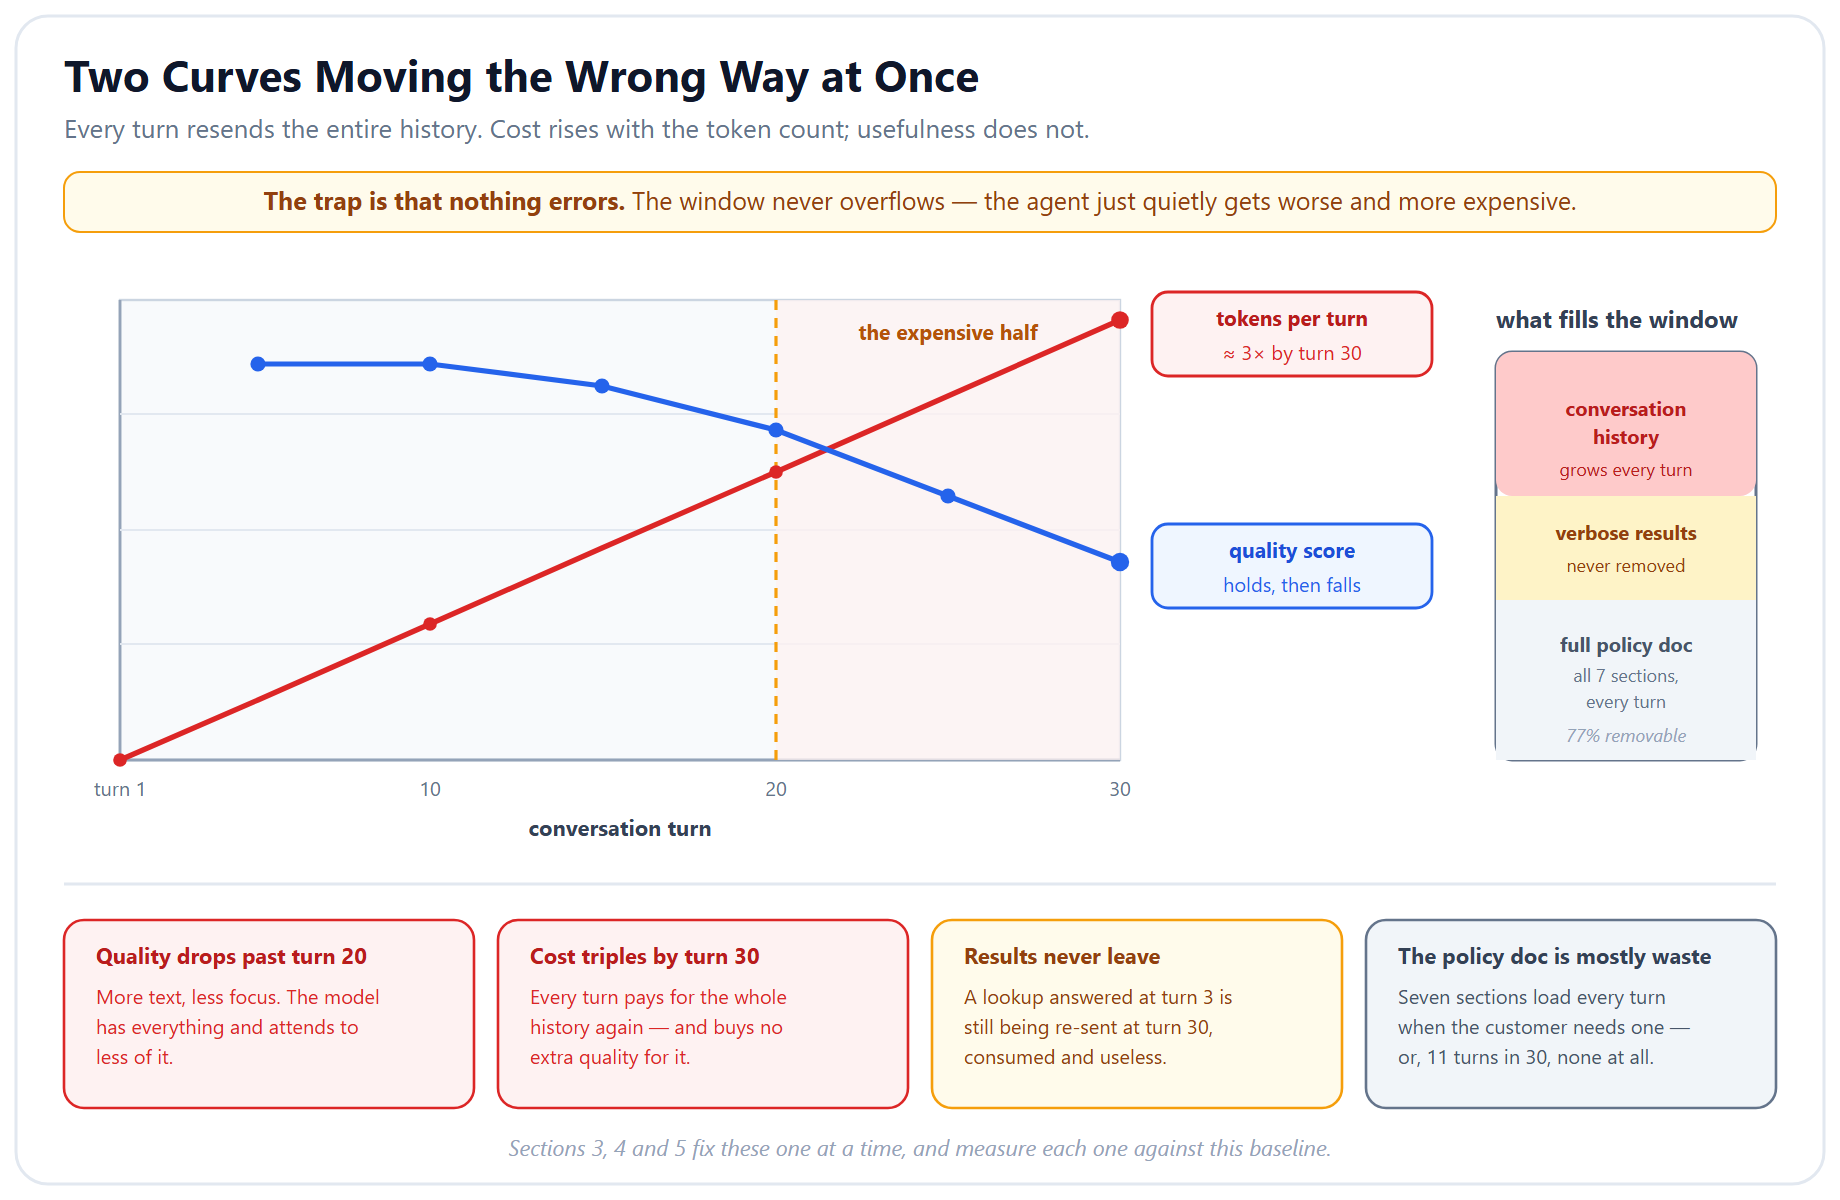

**Figure — Two curves moving the wrong way at once.** Every turn resends the whole history, so tokens climb linearly while the useful signal in them does not. Past roughly turn 20 the agent is paying three times as much to answer slightly worse — the model has more text and less focus. The window never overflows in this run, which is the trap: nothing errors, it just quietly gets worse and more expensive.

In [9]:
# --- The ShopSmart agent: a real tool-calling loop ---
# A deliberately light stand-in for a full support graph — one prompt and one tool
# loop per turn, so the context mechanics stay visible instead of being buried in a StateGraph.
# Same data, same tools, same policies: only the orchestration is simplified.
#
# Note what run_agent_turn() appends to the conversation: the customer's turn, the assistant's
# tool call, the FULL tool result, and the assistant's reply. All four stay in the window and all
# four are re-sent on every later turn. That is the growth this lab measures.
from langchain_core.prompts import MessagesPlaceholder

BASELINE_SYSTEM_PROMPT = """You are ShopSmart's customer support agent. Help customers with \
orders, returns, billing and product questions.

Use the tools to look up anything you do not already know from the conversation. Never invent an
order detail, price or date - look it up.

Be helpful, empathetic and concise. Use the customer's name when you know it. All amounts are in
US dollars."""

# The baseline pastes the ENTIRE policy document into every turn, whether the customer asked
# about shipping or not. Section 5 replaces this with just the section the turn needs.
FULL_POLICY_SYSTEM_PROMPT = (BASELINE_SYSTEM_PROMPT
                             + "\n\nSHOPSMART POLICIES\n" + ALL_POLICY_TEXT)

agent_prompt = ChatPromptTemplate.from_messages([
    ("system", "{system_prompt}"),
    MessagesPlaceholder("conversation"),
])
agent_with_tools = agent_prompt | chat_model.bind_tools(SHOPSMART_TOOLS)

MAX_TOOL_ROUNDS = 3          # a stuck agent should stop, not loop until the budget is gone


def run_agent_turn(query, conversation, ledger, system_prompt=FULL_POLICY_SYSTEM_PROMPT):
    """Run one customer turn end to end, appending everything it produces to `conversation`.

    Args:
        query: What the customer said this turn.
        conversation: The running message list. Modified in place.
        ledger: The RunLedger recording token spend.
        system_prompt: The system prompt to run this turn with.

    Returns:
        The agent's final text reply for this turn.
    """
    conversation.append(HumanMessage(content=query))
    for _ in range(MAX_TOOL_ROUNDS):
        reply = agent_with_tools.invoke(
            {"system_prompt": system_prompt, "conversation": conversation})
        ledger.record_agent_call(reply.usage_metadata)
        conversation.append(reply)
        if not reply.tool_calls:
            return str(reply.content)
        for tool_call in reply.tool_calls:
            selected_tool = TOOLS_BY_NAME[tool_call["name"]]
            # Passing the whole tool_call dict returns a ready-made ToolMessage whose
            # tool_call_id already matches — never hand-build one, or you risk the orphaned
            # result that section 8b shows the provider rejecting.
            conversation.append(selected_tool.invoke(tool_call))
    return str(conversation[-1].content)


print("Agent ready: gpt-4.1-mini with 4 tools.")
print(f"System prompt: {count_tokens(FULL_POLICY_SYSTEM_PROMPT):,} tokens "
      f"(the whole policy document, every turn).")

Agent ready: gpt-4.1-mini with 4 tools.
System prompt: 706 tokens (the whole policy document, every turn).


### 2.1 How we measure "it forgot"

An LLM judge that is shown one question and one answer cannot tell you whether the agent
remembered turn 3 — it never saw turn 3. Ask it to rate quality and it rates *plausibility*,
which is why a badly-instrumented version of this lab can show a flat, healthy-looking quality
line while the agent quietly loses the customer's own words.

So the primary instrument here is not a judge. It is three **recall probes** planted in the
script at turns 10, 20 and 30. Each one asks the agent to repeat a fact that

* the **customer** established earlier in the conversation, and
* appears in **no tool result and no system prompt**.

The daughter's name, the date the present is needed by, the defect the customer described, the
delivery instruction about the lift: none of these are in the order system. The only place they
exist is the conversation. Scoring is a substring check — no model, no variance, no opinion. A
failed probe is unambiguous evidence that a fact left the window.

A cross-family LLM judge still runs alongside, scoring answer quality with the conversation in
front of it. It is the secondary signal; the probes are the one that decides the argument.

In [10]:
# --- The 30-turn conversation, with three deterministic recall probes ---
# The customer is CUST-0002, Sarah Johnson, who has 19 real orders on file. Every order ID,
# product name and amount below is read from the data you loaded in section 1 — the agent can
# look all of it up, which is the point.
#
# `recall_terms` marks a PROBE turn. Every term listed there was established by the CUSTOMER and
# appears in no tool result and no system prompt, so the only way to answer is to still hold
# that turn in context. Section 1's join check is what makes that guarantee testable: we know
# what is in the data, so we know these four facts are not.
CONVERSATION_SCRIPT = [
    # Turns 1-5: the order, and the facts only the customer knows
    {"query": "Hi, I'm Sarah Johnson, customer CUST-0002. I placed order ORD-00001. "
              "What's the status?"},
    {"query": "It's a housewarming gift for my sister Deborah, and she moves in on the 30th. "
              "Will it get there in time?"},
    {"query": "Where exactly is the parcel right now?"},
    {"query": "What's the tracking number, and who is carrying it?"},
    {"query": "I work nights, so please have them leave it with the building manager rather "
              "than at the door."},

    # Turns 6-10: products, then the first probe
    {"query": "Separately, I'm looking at what else you have in Electronics. What's in stock?"},
    {"query": "How do the Wireless Headphones compare with the Bluetooth Speaker?"},
    {"query": "What's the price difference between those two?"},
    {"query": "Do the Wireless Headphones come with a warranty, and are they returnable?"},
    {"query": "Before I forget - who did I say this order was for, and what date do I need it by?",
     "recall_terms": ["deborah", "30th"]},

    # Turns 11-15: billing, using a second real order
    {"query": "I have a billing question about order ORD-00046. The charge doesn't look right."},
    {"query": "Can you confirm the payment ID and the exact amount that was captured?"},
    {"query": "What's the subtotal versus the order total on that one - was there shipping?"},
    {"query": "If I'm owed a refund, how long does it take and where does it go?"},
    {"query": "Can you also pull up my full order history? I want to check what else is open."},

    # Turns 16-20: the return, then the second probe
    {"query": "I want to return the Coffee Maker from ORD-00001. The carafe arrived cracked."},
    {"query": "Does a defect like that qualify for a full refund, and who pays return shipping?"},
    {"query": "What's the return process from here?"},
    {"query": "How long do I have to start the return?"},
    {"query": "Remind me what defect I reported, and the delivery instruction I gave you earlier.",
     "recall_terms": ["cracked", "building manager"]},

    # Turns 21-25: a second product thread
    {"query": "While we're here, I'm interested in the Sports category for Deborah's new place."},
    {"query": "Is the Dumbbells Set in stock, and what does it weigh?"},
    {"query": "Compare the Yoga Mat and the Resistance Bands for me."},
    {"query": "Which of those would you recommend for someone just starting out?"},
    {"query": "What about Home & Garden - what's the LED Desk Lamp like?"},

    # Turns 26-30: circle back, then the final probe
    {"query": "Going back to ORD-00001 - any delivery update?"},
    {"query": "Order ORD-00013 shows as cancelled. What happened there?"},
    {"query": "Was I refunded for ORD-00013, and when?"},
    {"query": "One of my orders has no tracking number at all - can you check ORD-00094?"},
    {"query": "Last thing: confirm my sister's name, the date I need ORD-00001 by, the defect I "
              "reported on the Coffee Maker, and the delivery instruction for my building.",
     "recall_terms": ["deborah", "30th", "cracked", "building manager"]},
]


def check_recall(answer, expected_terms):
    """Return True when the answer still contains every fact the customer established earlier.

    A plain substring check on purpose: no model is involved, so a failure is evidence about the
    agent's context rather than evidence about a grader's mood.

    Args:
        answer: The agent's reply to a probe turn.
        expected_terms: Facts that appear only in the conversation, never in a tool result.
    """
    lowered = answer.lower()
    return all(term.lower() in lowered for term in expected_terms)


# Prove the claim rather than asserting it: none of the probe facts may exist anywhere in the
# corpus the tools read from, or a passing probe would mean nothing.
corpus_text = (json.dumps(customers_raw) + json.dumps(orders_raw) + json.dumps(products_raw)
               + json.dumps(TICKETS) + POLICIES).lower()
probe_terms = sorted({term for step in CONVERSATION_SCRIPT
                      for term in step.get("recall_terms", [])})
leaked_terms = [term for term in probe_terms if term in corpus_text]

probe_turns = [position for position, step in enumerate(CONVERSATION_SCRIPT, start=1)
               if "recall_terms" in step]
print(f"Conversation script: {len(CONVERSATION_SCRIPT)} turns.")
print(f"Recall probes at turns: {probe_turns}")
print(f"Facts under test: {probe_terms}")
print(f"Any of them findable in the data the tools read? {leaked_terms or 'no - none of them'}")

Conversation script: 30 turns.
Recall probes at turns: [10, 20, 30]
Facts under test: ['30th', 'building manager', 'cracked', 'deborah']
Any of them findable in the data the tools read? no - none of them


In [11]:
# --- One function that runs the whole conversation under any configuration ---
# Every configuration in this lab is this same function with different switches, so the
# comparison in section 7 is like-for-like by construction.
QUALITY_SCORE_EVERY = 5          # judge every 5th turn; the probes cover every probe turn


def run_configuration(name, compact_every_turn=False, compact_on_trigger=False,
                      clear_tool_results=False, use_jit_prompt=False, verbose=True):
    """Run the 30-turn script under one configuration and return its ledger.

    Args:
        name: Label for the configuration.
        compact_every_turn: Fix 1, applied naively — summarise before every single turn.
        compact_on_trigger: Fix 1, applied properly — summarise only once the window crosses
            COMPACTION_TRIGGER_TOKENS.
        clear_tool_results: Fix 2 — blank the older tool results, keep the messages.
        use_jit_prompt: Fix 3 — load only the FAQ section this turn needs.
        verbose: Print a progress line for milestone turns and every probe.

    Returns:
        The RunLedger for the run, carrying token spend, window sizes, quality scores and probes.
    """
    ledger = RunLedger(name)
    conversation = []
    if verbose:
        print(f"\n{name}")
        print("-" * 62)

    for position, step in enumerate(CONVERSATION_SCRIPT, start=1):
        if compact_every_turn:
            conversation = compact_conversation(conversation, ledger, trigger_tokens=0)
        elif compact_on_trigger:
            conversation = compact_conversation(conversation, ledger)
        if clear_tool_results:
            conversation = clear_old_tool_results(conversation)

        system_prompt = (build_jit_system_prompt(step["query"]) if use_jit_prompt
                         else FULL_POLICY_SYSTEM_PROMPT)
        answer = run_agent_turn(step["query"], conversation, ledger, system_prompt=system_prompt)

        ledger.window_tokens_per_turn.append(
            count_message_tokens(conversation) + count_tokens(system_prompt))

        if position % QUALITY_SCORE_EVERY == 0:
            ledger.quality_scores.append((position, score_quality(step["query"], answer,
                                                                  conversation)))
        verdict = ""
        if "recall_terms" in step:
            was_recalled = check_recall(answer, step["recall_terms"])
            ledger.probe_results.append((position, was_recalled))
            missing = [term for term in step["recall_terms"] if term.lower() not in answer.lower()]
            verdict = "   probe PASSED" if was_recalled else f"   probe FAILED - lost: {', '.join(missing)}"
        if verbose and (position % QUALITY_SCORE_EVERY == 0 or verdict):
            print(f"  turn {position:2d}: window={ledger.window_tokens_per_turn[-1]:6,} tokens"
                  f"{verdict}")
    return ledger


print("Runner ready. Each configuration below is the same function with different switches.")

Runner ready. Each configuration below is the same function with different switches.


In [12]:
# --- Run the baseline: no context management at all ---
# About 40 model calls and a couple of minutes. Everything the tools return stays in the window
# and is re-sent on every later turn.
baseline_ledger = run_configuration("Baseline - no context management")

peak = baseline_ledger.peak_window_tokens
print(f"\nPeak window        : {peak:,} tokens "
      f"({peak / 128_000 * 100:.0f}% of a 128K window; "
      f"{'it would OVERFLOW' if peak > 32_000 else 'it fits'} a 32K model)")
print(f"Input tokens paid  : {baseline_ledger.total_input_tokens:,}")
print(f"Output tokens paid : {baseline_ledger.total_output_tokens:,}")
print(f"Model calls        : {baseline_ledger.model_calls}")
print(f"Cost of ONE call   : ${baseline_ledger.total_cost_dollars():.4f}")
print(f"Recall probes      : {baseline_ledger.recall_score()[0]}/{baseline_ledger.recall_score()[1]} passed")
print(f"\nAt 10,000 conversations a day that is "
      f"${baseline_ledger.total_cost_dollars() * 10_000:,.2f} per day.")


Baseline - no context management
--------------------------------------------------------------


  turn  5: window= 2,775 tokens


  turn 10: window= 3,817 tokens   probe PASSED


  turn 15: window= 8,772 tokens


  turn 20: window= 9,304 tokens   probe PASSED


  turn 25: window=10,460 tokens


  turn 30: window=11,745 tokens   probe PASSED

Peak window        : 11,745 tokens (9% of a 128K window; it fits a 32K model)
Input tokens paid  : 254,377
Output tokens paid : 2,576
Model calls        : 37
Cost of ONE call   : $0.1059
Recall probes      : 3/3 passed

At 10,000 conversations a day that is $1,058.72 per day.


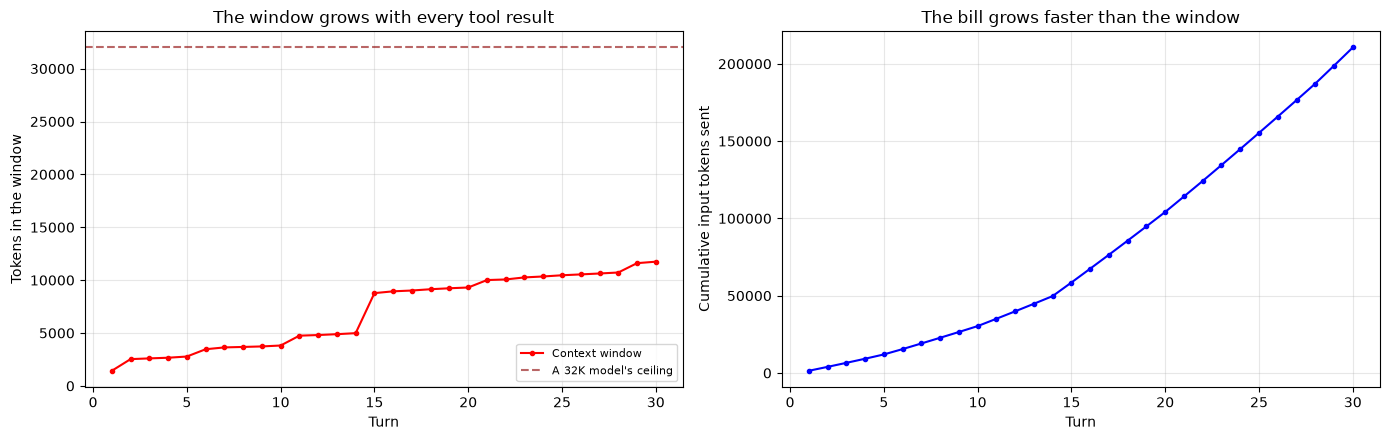

Window at turn 1 : 1,428 tokens
Window at turn 30: 11,745 tokens (8.2x)
Tokens sent in total: 254,377 - that is the number on the invoice, and it is what the fixes have to reduce.


In [13]:
# --- What the baseline actually looks like ---
figure, (window_axis, spend_axis) = plt.subplots(1, 2, figsize=(14, 4.5))
turns = list(range(1, len(baseline_ledger.window_tokens_per_turn) + 1))

window_axis.plot(turns, baseline_ledger.window_tokens_per_turn, "r-o", markersize=3,
                 label="Context window")
window_axis.axhline(y=32_000, color="darkred", linestyle="--", alpha=0.6,
                    label="A 32K model's ceiling")
window_axis.set_xlabel("Turn")
window_axis.set_ylabel("Tokens in the window")
window_axis.set_title("The window grows with every tool result")
window_axis.legend(fontsize=8)
window_axis.grid(True, alpha=0.3)

# The bill is the cumulative sum of what was sent, not the size of the window: every turn
# re-sends the whole history, so spend grows quadratically while the window grows linearly.
cumulative_tokens = []
running_total = 0
for window_tokens in baseline_ledger.window_tokens_per_turn:
    running_total += window_tokens
    cumulative_tokens.append(running_total)
spend_axis.plot(turns, cumulative_tokens, "b-o", markersize=3)
spend_axis.set_xlabel("Turn")
spend_axis.set_ylabel("Cumulative input tokens sent")
spend_axis.set_title("The bill grows faster than the window")
spend_axis.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Window at turn 1 : {baseline_ledger.window_tokens_per_turn[0]:,} tokens")
print(f"Window at turn 30: {baseline_ledger.window_tokens_per_turn[-1]:,} tokens "
      f"({baseline_ledger.window_tokens_per_turn[-1] / baseline_ledger.window_tokens_per_turn[0]:.1f}x)")
print(f"Tokens sent in total: {baseline_ledger.total_input_tokens:,} - "
      f"that is the number on the invoice, and it is what the fixes have to reduce.")

## 3. Fix 1 — History Compaction (Summarise the Old Turns)

Instead of carrying all 30 turns of raw history, **summarise the older messages** and keep the recent ones verbatim. This is the fix everyone reaches for first.

It is also the only one in this lab that spends a model call to save a model call, and the only one that rewrites what the customer said rather than what a tool returned. We run it **twice** — compacting on every turn, and compacting only once the window crosses a trigger — because that single configuration choice changes both what it saves and what it forgets.

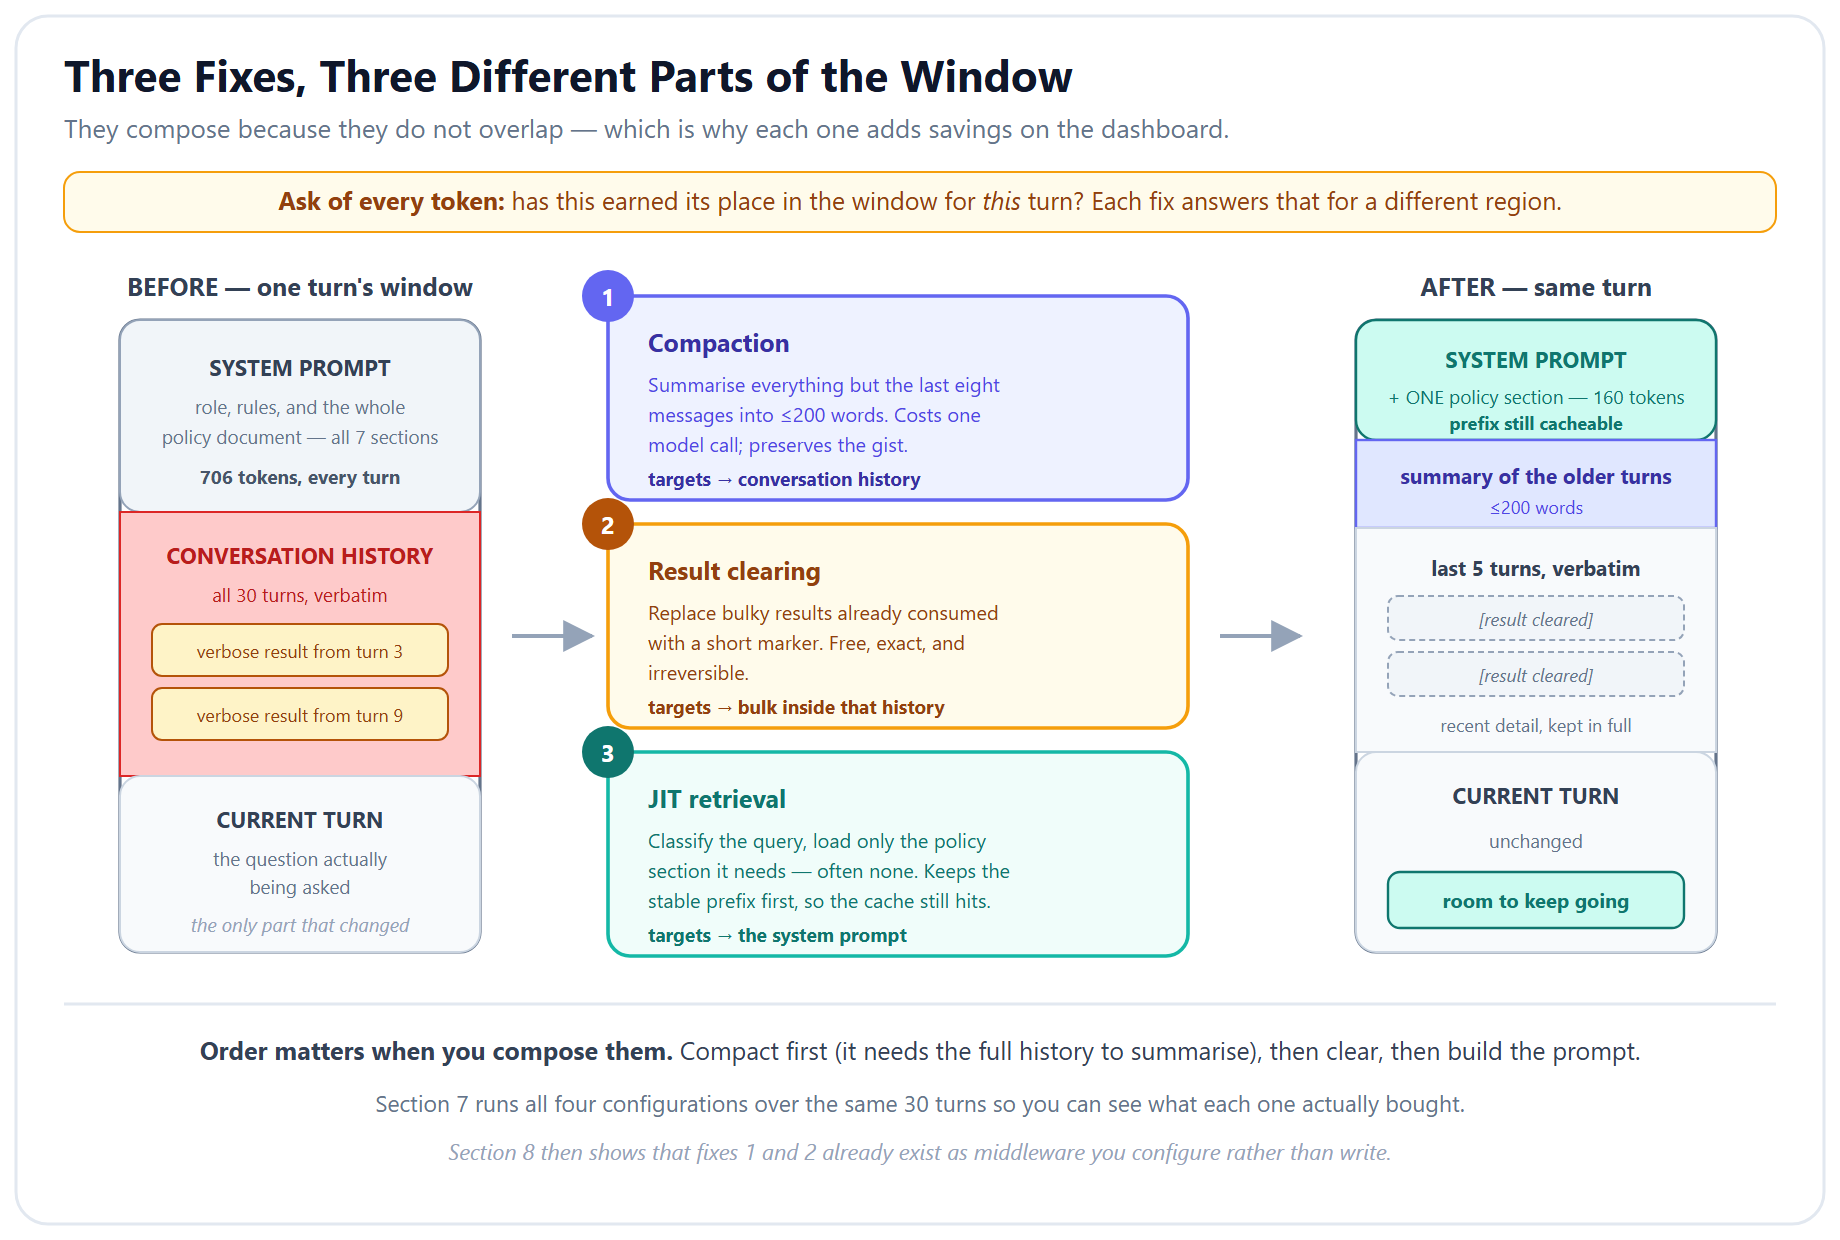

**Figure — Three fixes, three different parts of the window.** Compaction attacks the conversation history, clearing attacks bulky results inside it, and JIT retrieval attacks the system prompt itself. They compose because they do not overlap — which is why the dashboard in section 7 shows each one adding savings rather than replacing the last.

In [14]:
# --- Fix 1: history compaction ---
# The instinctive fix: summarise the old turns and keep the recent ones verbatim.
#
# The trigger is the part everyone skips. Compacting on EVERY turn re-summarises the previous
# summary again and again, and each pass is another chance to drop a fact the customer gave you.
# Both variants run below so you can see what that choice costs.
summarize_prompt = ChatPromptTemplate.from_template(
    """Summarise this customer-support conversation in at most 200 words.

PRESERVE, verbatim where you can: the customer's name and anyone they named, every order ID,
every date the customer gave, every amount, the reason for any return, and any delivery
instruction the customer asked for. These are the facts the agent will be asked about later.

DROP: pleasantries, tool output that has already been acted on, repeated information.

Conversation:
{conversation}

Summary:""")

summarize_chain = summarize_prompt | chat_model

COMPACTION_TRIGGER_TOKENS = 6_000


def compact_conversation(conversation, ledger, keep_last_messages=8,
                         trigger_tokens=COMPACTION_TRIGGER_TOKENS):
    """Summarise the older messages once the conversation crosses `trigger_tokens`.

    Args:
        conversation: The running message list.
        ledger: The RunLedger, which is billed for the summariser call.
        keep_last_messages: How many recent messages survive verbatim.
        trigger_tokens: Compact only above this size. 0 means compact on every turn.

    Returns:
        A NEW message list: one summary message followed by the recent messages.
    """
    if len(conversation) <= keep_last_messages:
        return conversation
    if count_message_tokens(conversation) < trigger_tokens:
        return conversation

    older_messages = conversation[:-keep_last_messages]
    recent_messages = conversation[-keep_last_messages:]
    # Never cut between an AIMessage carrying tool_calls and the ToolMessages answering it: the
    # provider rejects a history with an unanswered tool call. Section 8b shows that error.
    while recent_messages and isinstance(recent_messages[0], ToolMessage):
        older_messages.append(recent_messages.pop(0))

    transcript = "\n".join(f"{message.type}: {str(message.content)[:600]}"
                           for message in older_messages)
    summary_reply = summarize_chain.invoke({"conversation": transcript})
    ledger.record_summariser_call(summary_reply.usage_metadata)
    return [SystemMessage(content=f"[Summary of the conversation so far: "
                                  f"{summary_reply.content}]")] + recent_messages


print("Compaction ready.")
print(f"Trigger: summarise only once the window passes {COMPACTION_TRIGGER_TOKENS:,} tokens.")

Compaction ready.
Trigger: summarise only once the window passes 6,000 tokens.


In [15]:
# --- Run Fix 1 twice: compacting every turn, and compacting on a trigger ---
# Same summariser, same prompt, same conversation. The only difference is WHEN it fires.
naive_compaction_ledger = run_configuration("Fix 1 - compaction on EVERY turn",
                                            compact_every_turn=True)
compaction_ledger = run_configuration("Fix 1 - compaction on a TRIGGER",
                                      compact_on_trigger=True)

print("\n" + "=" * 78)
print(f"{'':<34}{'peak window':>13}{'total tokens':>14}{'summariser':>12}{'probes':>9}")
print("-" * 78)
for ledger in (baseline_ledger, naive_compaction_ledger, compaction_ledger):
    passed, total = ledger.recall_score()
    summariser_tokens = ledger.summariser_input_tokens + ledger.summariser_output_tokens
    print(f"{ledger.configuration_name:<34}{ledger.peak_window_tokens:>13,}"
          f"{ledger.total_input_tokens + ledger.total_output_tokens:>14,}"
          f"{summariser_tokens:>12,}{f'{passed}/{total}':>9}")

print("\nCompacting every turn saves more and remembers less - it is not a better fix, it is a")
print("more aggressive one. The summariser tokens column is the cost the saving is net of.")


Fix 1 - compaction on EVERY turn
--------------------------------------------------------------


  turn  5: window= 2,182 tokens


  turn 10: window= 1,343 tokens   probe FAILED - lost: 30th


  turn 15: window= 5,108 tokens


  turn 20: window= 1,590 tokens   probe FAILED - lost: building manager


...

  turn 10: window= 3,797 tokens   probe PASSED


  turn 15: window= 8,752 tokens


  turn 20: window= 5,538 tokens   probe PASSED


  turn 25: window= 6,891 tokens


  turn 30: window= 4,969 tokens   probe FAILED - lost: 30th

                                    peak window  total tokens  summariser   probes
------------------------------------------------------------------------------
Baseline - no context management         11,745       256,953           0      3/3
Fix 1 - compaction on EVERY turn          6,757       136,200      15,931      0/3
Fix 1 - compaction on a TRIGGER           8,752       189,181       4,319      2/3

Compacting every turn saves more and remembers less - it is not a better fix, it is a
more aggressive one. The summariser tokens column is the cost the saving is net of.


## 4. Fix 2 — Clearing the Tool Results You Have Already Read

Order lookups and shipment tracking return raw JSON that then sits in the history forever. The agent read it once, answered with it, and will never need the raw payload again.

So blank the content and **keep the message**. Deleting a `ToolMessage` outright would orphan the tool call that asked for it, and the provider rejects that history — section 8b shows the exact error. Keeping the message and emptying it is precisely what LangChain's `ClearToolUsesEdit` does, which is why this section and section 8 finally agree with each other.

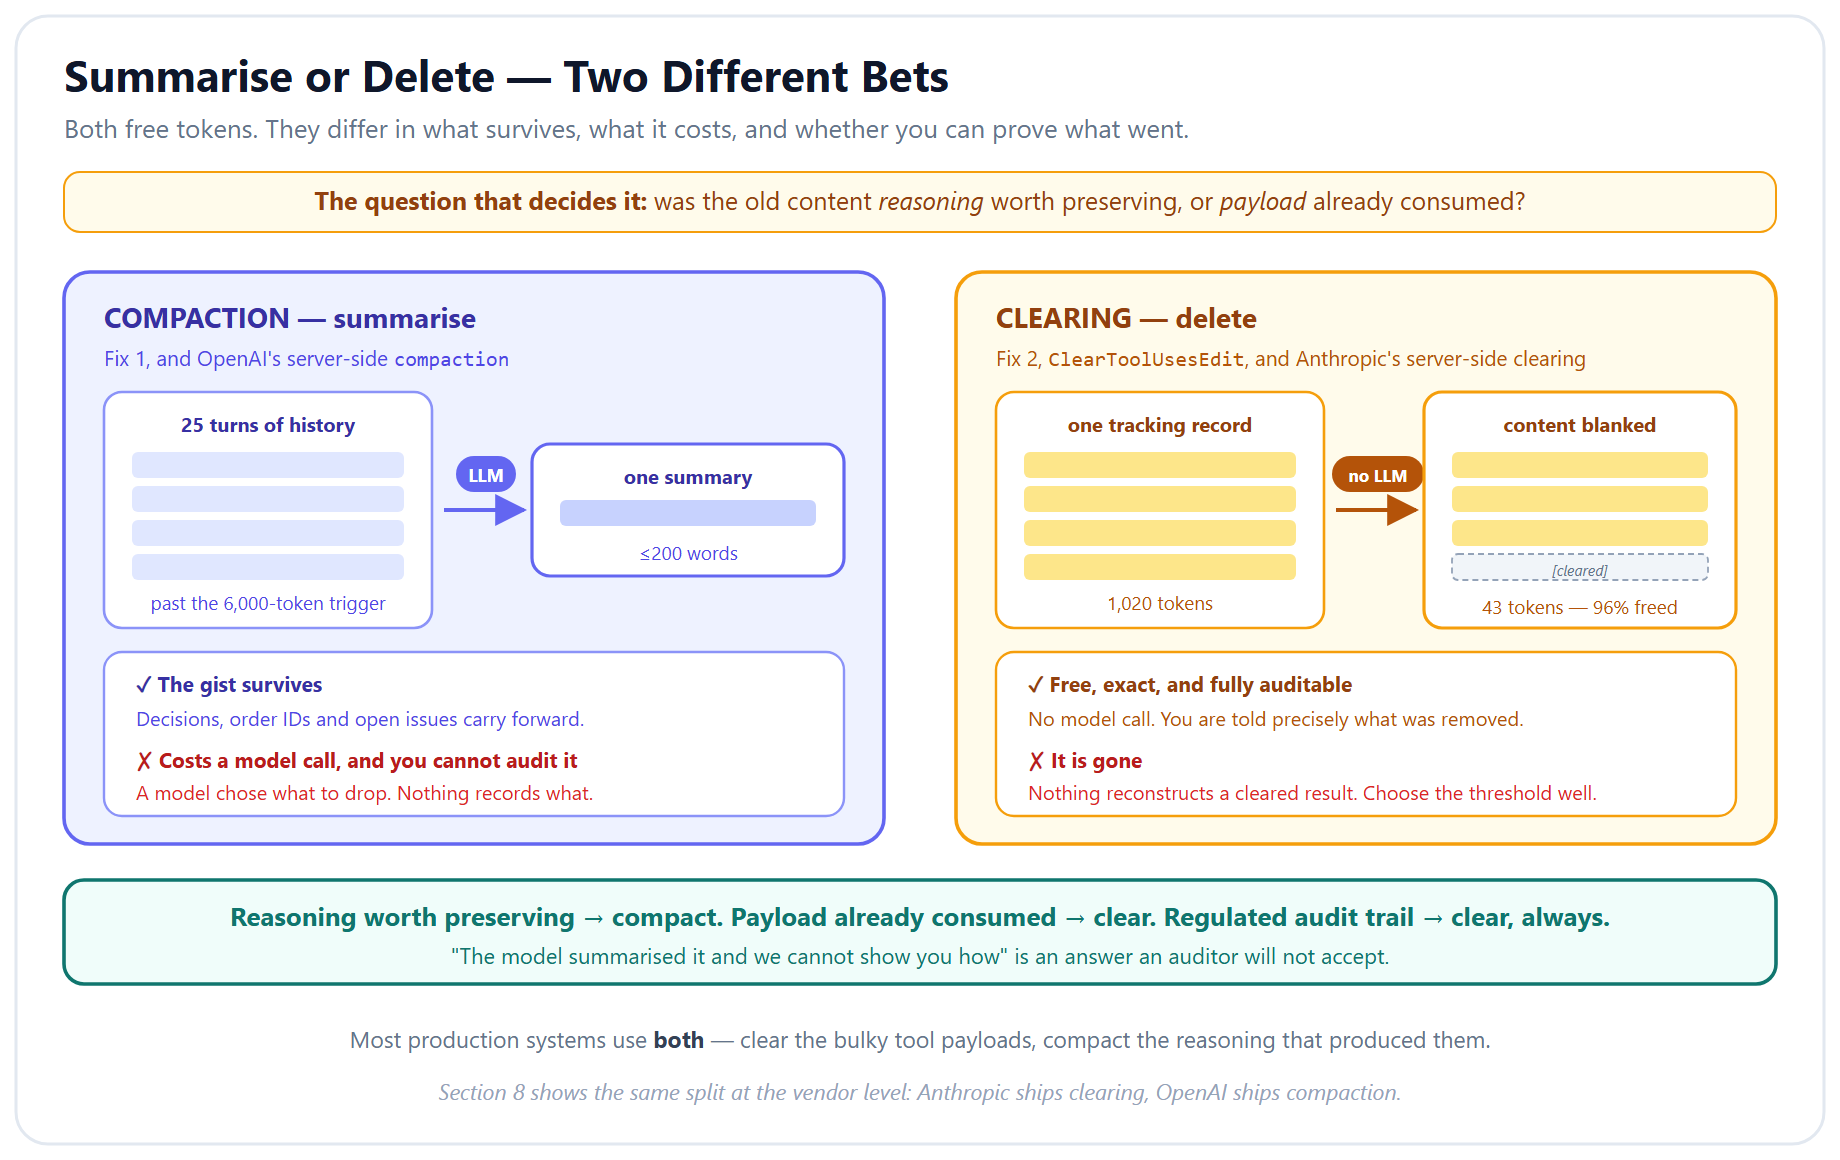

**Figure — Summarise or delete: two different bets.** Compaction spends a model call to preserve the gist, and what it drops is chosen by a model you cannot fully predict. Clearing is free and exact — you know precisely what went — but it is gone. The right choice depends on whether the old content was *reasoning* worth preserving or *payload* already consumed.

In [16]:
# --- Fix 2: clear the old tool results, keep the tool messages ---
# The agent read that JSON once, acted on it, and answered. Keeping the full payload for the
# remaining twenty turns buys nothing - but DELETING the message would orphan its tool call, and
# the provider rejects a history whose tool call has no result (section 8b shows the error).
#
# So blank the content and keep the message. This is exactly what ClearToolUsesEdit does in
# section 8, and it is the reason that middleware exists.
def clear_old_tool_results(conversation, keep_last_results=2, placeholder="[cleared]"):
    """Blank the content of older tool results while keeping each ToolMessage in place.

    Args:
        conversation: The running message list.
        keep_last_results: How many of the most recent tool results survive intact.
        placeholder: What replaces a cleared payload.

    Returns:
        A NEW message list, with the same messages in the same order and the same tool_call_ids.
    """
    tool_positions = [position for position, message in enumerate(conversation)
                      if isinstance(message, ToolMessage)]
    positions_to_clear = set(tool_positions[:-keep_last_results] if keep_last_results
                             else tool_positions)
    rebuilt = []
    for position, message in enumerate(conversation):
        if position in positions_to_clear and str(message.content) != placeholder:
            rebuilt.append(ToolMessage(content=placeholder, name=message.name,
                                       tool_call_id=message.tool_call_id))
        else:
            rebuilt.append(message)
    return rebuilt


# What it does to one conversation, before running the whole thing again:
demonstration = [HumanMessage(content="Where is ORD-00001?"),
                 AIMessage(content="", tool_calls=[{"name": "track_shipment",
                                                    "args": {"order_id": "ORD-00001"},
                                                    "id": "call_demo"}]),
                 ToolMessage(content=json.dumps(build_shipment_record("ORD-00001"), indent=2),
                             tool_call_id="call_demo"),
                 HumanMessage(content="And ORD-00046?")]
before_tokens = count_message_tokens(demonstration)
after_tokens = count_message_tokens(clear_old_tool_results(demonstration, keep_last_results=0))
print(f"One tracking record in the window : {before_tokens:,} tokens")
print(f"After clearing it                 : {after_tokens:,} tokens "
      f"({(1 - after_tokens / before_tokens) * 100:.0f}% freed, tool_call_id intact)")

One tracking record in the window : 1,020 tokens
After clearing it                 : 43 tokens (96% freed, tool_call_id intact)


In [17]:
# --- Run Fix 1 + Fix 2 together ---
clearing_ledger = run_configuration("Fix 1 + 2 - compaction and tool-result clearing",
                                    compact_on_trigger=True, clear_tool_results=True)

passed, total = clearing_ledger.recall_score()
baseline_total = baseline_ledger.total_input_tokens + baseline_ledger.total_output_tokens
clearing_total = clearing_ledger.total_input_tokens + clearing_ledger.total_output_tokens
print(f"\nTotal tokens vs baseline: {(1 - clearing_total / baseline_total) * 100:.0f}% saved")
print(f"Recall probes           : {passed}/{total} passed")
print("\nClearing tool results drops MORE tokens than summarising did, and it drops nothing the")
print("customer said - only JSON the agent had already read. What you throw away matters more")
print("than how much of it you throw away.")


Fix 1 + 2 - compaction and tool-result clearing
--------------------------------------------------------------


  turn  5: window= 2,731 tokens


  turn 10: window= 3,180 tokens   probe PASSED


  turn 15: window= 7,150 tokens


  turn 20: window= 5,595 tokens   probe PASSED


  turn 25: window= 1,824 tokens


  turn 30: window= 4,071 tokens   probe FAILED - lost: 30th

Total tokens vs baseline: 35% saved
Recall probes           : 2/3 passed

Clearing tool results drops MORE tokens than summarising did, and it drops nothing the
customer said - only JSON the agent had already read. What you throw away matters more
than how much of it you throw away.


## 5. Fix 3 — Just-In-Time Policy Retrieval

Instead of pasting the whole policy document into every turn, **classify the query** and load only the section it needs — and, when the turn needs no policy at all, load nothing. The cell below prints the before and after size, and where each of the 30 turns routes. Read the measured numbers rather than trusting a round one.

Note the ordering inside the prompt: the stable text first, the varying section last. That is deliberate, and section 8c explains what it is protecting.

In [18]:
# --- Fix 3: just-in-time policy retrieval ---
# The baseline pastes the entire policy document into every single turn. A customer asking where
# their parcel is does not need the returns policy, the billing policy or the escalation matrix.
#
# The sections are the ones policies.md actually declares — we read them in section 1 rather
# than inventing a taxonomy, so this classifier keeps working if the policy document changes.
POLICY_ROUTING_KEYWORDS = {
    "return_refund_policy": ["return", "refund", "defect", "cracked", "damaged", "replace",
                             "exchange", "pickup"],
    "shipping_policy": ["ship", "deliver", "track", "parcel", "carrier", "arrive", "where is"],
    "billing_payment_policy": ["charge", "bill", "payment", "invoice", "card", "captured",
                               "subtotal", "total"],
    "order_modification_cancellation": ["cancel", "modify", "change my order", "amend"],
    "customer_service_escalation_criteria": ["manager", "supervisor", "complain", "escalate",
                                             "unacceptable"],
    "technical_support": ["log in", "login", "password", "account access", "website", "app"],
    "special_circumstances": ["gift", "bulk", "wholesale", "international"],
}


def classify_policy_section(query):
    """Pick the one policy section a customer turn actually needs.

    Args:
        query: What the customer said this turn.

    Returns:
        One key of POLICY_SECTIONS. Falls back to the shipping policy, which is what the
        largest share of support traffic is about.
    """
    lowered = query.lower()
    for section_key, keywords in POLICY_ROUTING_KEYWORDS.items():
        if section_key in POLICY_SECTIONS and any(word in lowered for word in keywords):
            return section_key
    # No section matched. A question about a product's specifications is not a policy question,
    # and the cheapest retrieval is the one you do not perform - so return None and let the
    # prompt carry no policy block at all.
    return None


def build_jit_system_prompt(query):
    """Build a system prompt carrying only the policy section this turn needs, if any.

    The stable text comes FIRST and the varying section LAST, so the cacheable prefix survives
    from turn to turn - see section 8c on why compaction and caching pull against each other.

    Args:
        query: What the customer said this turn.

    Returns:
        The system prompt for this turn. When no policy section is relevant, that is the
        baseline prompt on its own.
    """
    section_key = classify_policy_section(query)
    if section_key is None:
        return BASELINE_SYSTEM_PROMPT
    return f"""{BASELINE_SYSTEM_PROMPT}

Relevant policy ({section_key}):
{POLICY_SECTIONS[section_key]}"""


full_prompt_tokens = count_tokens(FULL_POLICY_SYSTEM_PROMPT)
jit_prompt_tokens = count_tokens(build_jit_system_prompt("Where is my order?"))
print(f"System prompt, the whole policy document : {full_prompt_tokens:,} tokens")
print(f"System prompt, just-in-time              : {jit_prompt_tokens:,} tokens "
      f"({(1 - jit_prompt_tokens / full_prompt_tokens) * 100:.0f}% smaller)")
print(f"Saved on EVERY one of the {len(CONVERSATION_SCRIPT)} turns, and on every tool round "
      f"inside them.")
print()
print("Where each turn of the script routes:")
routed_counts = {}
for step in CONVERSATION_SCRIPT:
    section_key = classify_policy_section(step["query"]) or "(no policy section needed)"
    routed_counts[section_key] = routed_counts.get(section_key, 0) + 1
for section_key, count in sorted(routed_counts.items(), key=lambda entry: -entry[1]):
    print(f"  {section_key:<38} {count:>2} turns")
print()
print("The largest bucket is usually the empty one, and that is the finding: most turns in a")
print("support conversation are not policy questions at all.")

System prompt, the whole policy document : 706 tokens
System prompt, just-in-time              : 160 tokens (77% smaller)
Saved on EVERY one of the 30 turns, and on every tool round inside them.

Where each turn of the script routes:
  (no policy section needed)             11 turns
  return_refund_policy                    9 turns
  shipping_policy                         5 turns
  billing_payment_policy                  2 turns
  special_circumstances                   1 turns
  customer_service_escalation_criteria    1 turns
  order_modification_cancellation         1 turns

The largest bucket is usually the empty one, and that is the finding: most turns in a
support conversation are not policy questions at all.


In [19]:
# --- Run all three fixes together ---
all_fixes_ledger = run_configuration("Fix 1 + 2 + 3 - all three",
                                     compact_on_trigger=True, clear_tool_results=True,
                                     use_jit_prompt=True)

passed, total = all_fixes_ledger.recall_score()
all_fixes_total = all_fixes_ledger.total_input_tokens + all_fixes_ledger.total_output_tokens
print(f"\nTotal tokens vs baseline: {(1 - all_fixes_total / baseline_total) * 100:.0f}% saved")
print(f"Cost of ONE conversation: ${all_fixes_ledger.total_cost_dollars():.4f} "
      f"(baseline was ${baseline_ledger.total_cost_dollars():.4f})")
print(f"Recall probes           : {passed}/{total} passed")


Fix 1 + 2 + 3 - all three
--------------------------------------------------------------


  turn  5: window= 2,239 tokens


  turn 10: window= 2,591 tokens   probe PASSED


  turn 15: window= 6,572 tokens


  turn 20: window= 5,000 tokens   probe PASSED


  turn 25: window= 6,267 tokens


  turn 30: window= 5,281 tokens   probe FAILED - lost: 30th

Total tokens vs baseline: 35% saved
Cost of ONE conversation: $0.0712 (baseline was $0.1059)
Recall probes           : 2/3 passed


## 6. A Token Budget for a 128K Window

How should you allocate a 128K window? The budget below is built from the runs you have just done — every line is measured, not assumed.

Read it together with the honest caveat it prints: a 30-turn support conversation does not come close to filling 128K. A budget like this earns its keep on **agentic** runs, where a single task can make dozens of tool calls and the numbers in section 8 (a 12-call history of about 47,000 tokens) become the normal case rather than the extreme one.

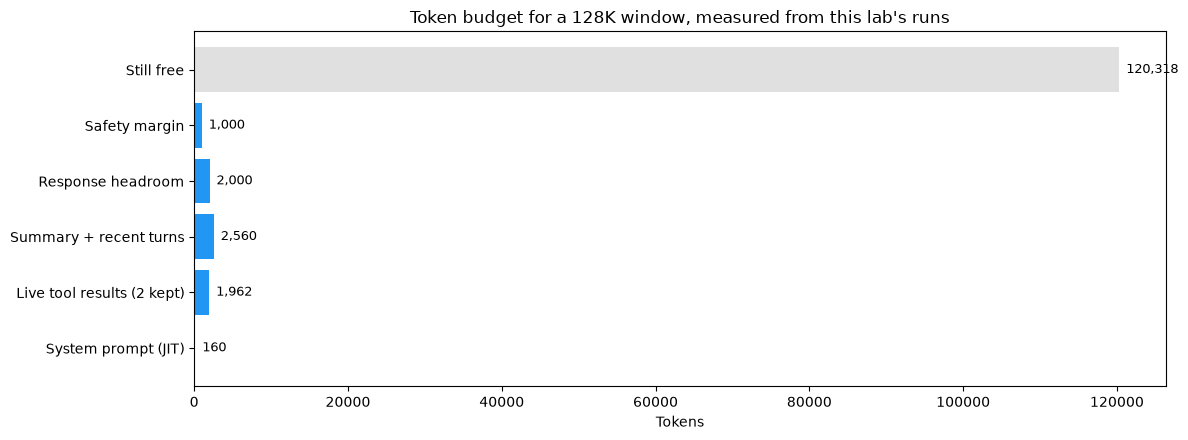

Working set with all three fixes on : 7,682 tokens (6.0% of 128K)
Baseline's peak, for comparison    : 11,745 tokens (9.2% of 128K)

Neither number is anywhere near 128K, and that is worth saying plainly: at 30 turns of
customer support the window is not what bites you. The bill is. A budget like this earns
its keep on agentic runs - dozens of tool calls per turn - not on conversations this size.


In [20]:
# --- A token budget, built from what this lab measured ---
# Not an illustration: every number below is read off the runs you just did.
live_tool_result_tokens = 2 * count_tokens(json.dumps(build_shipment_record("ORD-00001"), indent=2))
average_window_at_the_end = int(sum(all_fixes_ledger.window_tokens_per_turn[-5:]) / 5)

measured_budget = {
    "System prompt (JIT)": count_tokens(build_jit_system_prompt("Where is my order?")),
    "Live tool results (2 kept)": live_tool_result_tokens,
    # Whatever the working window holds beyond the system prompt and the two live tool results
    # is summary plus recent conversation — measured, not guessed.
    "Summary + recent turns": max(
        average_window_at_the_end
        - count_tokens(build_jit_system_prompt("Where is my order?"))
        - live_tool_result_tokens, 0),
    "Response headroom": 2_000,
    "Safety margin": 1_000,
}
measured_budget["Still free"] = 128_000 - sum(measured_budget.values())

figure, axis = plt.subplots(figsize=(12, 4.5))
labels = list(measured_budget)
values = list(measured_budget.values())
colors = ["#2196F3"] * (len(labels) - 1) + ["#E0E0E0"]
bars = axis.barh(labels, values, color=colors)
axis.set_xlabel("Tokens")
axis.set_title("Token budget for a 128K window, measured from this lab's runs")
for bar_patch, bar_value in zip(bars, values):
    axis.text(bar_patch.get_width() + 900, bar_patch.get_y() + bar_patch.get_height() / 2,
              f"{bar_value:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

used = sum(value for label, value in measured_budget.items() if label != "Still free")
print(f"Working set with all three fixes on : {used:,} tokens ({used / 128_000 * 100:.1f}% of 128K)")
print(f"Baseline's peak, for comparison    : {baseline_ledger.peak_window_tokens:,} tokens "
      f"({baseline_ledger.peak_window_tokens / 128_000 * 100:.1f}% of 128K)")
print("\nNeither number is anywhere near 128K, and that is worth saying plainly: at 30 turns of")
print("customer support the window is not what bites you. The bill is. A budget like this earns")
print("its keep on agentic runs - dozens of tool calls per turn - not on conversations this size.")

## 7. Before / After Dashboard

All five configurations, across the full 30-turn conversation: what each one saved, what each one cost, and — the column that matters — what each one could still remember.

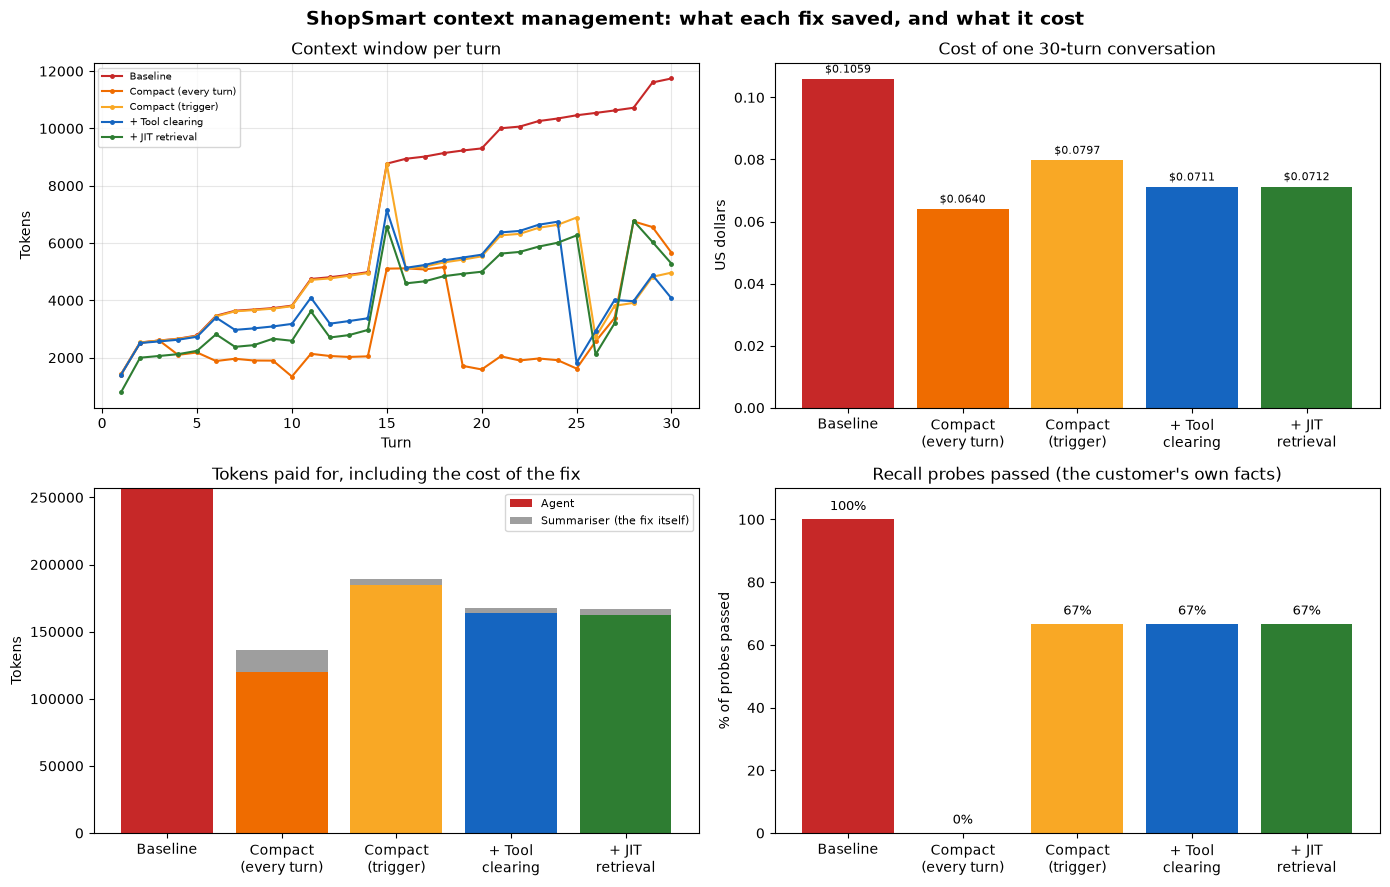

configuration                              peak     tokens   cost USD   recall  quality
--------------------------------------------------------------------------------------
Baseline - no context management         11,745    256,953     0.1059      3/3      4.3
Fix 1 - compaction on EVERY turn          6,757    136,200     0.0640      0/3      3.8
Fix 1 - compaction on a TRIGGER           8,752    189,181     0.0797      2/3      3.3
Fix 1 + 2 - compaction and tool-result clearing    7,150    167,401     0.0711      2/3      4.3
Fix 1 + 2 + 3 - all three                 6,778    167,191     0.0712      2/3      4.2

Read the last two columns against the baseline row. Every fix bought tokens back.
Clearing and JIT retrieval only ever drop tool output and policy text, so they cannot lose
a fact the customer gave. Compaction rewrites the customer's own words: compare its recall
with the baseline's — above all when it runs on every turn.


In [21]:
# --- Before / after, across every configuration ---
all_ledgers = [baseline_ledger, naive_compaction_ledger, compaction_ledger,
               clearing_ledger, all_fixes_ledger]
short_names = ["Baseline", "Compact\n(every turn)", "Compact\n(trigger)",
               "+ Tool\nclearing", "+ JIT\nretrieval"]
palette = ["#C62828", "#EF6C00", "#F9A825", "#1565C0", "#2E7D32"]

figure, axes = plt.subplots(2, 2, figsize=(14, 9))

# Top-left: the window, turn by turn.
for ledger, name, color in zip(all_ledgers, short_names, palette):
    axes[0, 0].plot(range(1, len(ledger.window_tokens_per_turn) + 1),
                    ledger.window_tokens_per_turn, "-o", markersize=2.5, color=color,
                    label=name.replace("\n", " "))
axes[0, 0].set_title("Context window per turn")
axes[0, 0].set_xlabel("Turn")
axes[0, 0].set_ylabel("Tokens")
axes[0, 0].legend(fontsize=7)
axes[0, 0].grid(True, alpha=0.3)

# Top-right: what each configuration actually cost.
costs = [ledger.total_cost_dollars() for ledger in all_ledgers]
axes[0, 1].bar(short_names, costs, color=palette)
axes[0, 1].set_title("Cost of one 30-turn conversation")
axes[0, 1].set_ylabel("US dollars")
for position, cost in enumerate(costs):
    axes[0, 1].text(position, cost + max(costs) * 0.02, f"${cost:.4f}", ha="center", fontsize=8)

# Bottom-left: total tokens, split into what the agent spent and what the fix spent.
agent_totals = [ledger.agent_input_tokens + ledger.agent_output_tokens for ledger in all_ledgers]
summariser_totals = [ledger.summariser_input_tokens + ledger.summariser_output_tokens
                     for ledger in all_ledgers]
axes[1, 0].bar(short_names, agent_totals, color=palette, label="Agent")
axes[1, 0].bar(short_names, summariser_totals, bottom=agent_totals, color="#9E9E9E",
               label="Summariser (the fix itself)")
axes[1, 0].set_title("Tokens paid for, including the cost of the fix")
axes[1, 0].set_ylabel("Tokens")
axes[1, 0].legend(fontsize=8)

# Bottom-right: what each configuration could still remember.
recall_percentages = [(ledger.recall_score()[0] / max(ledger.recall_score()[1], 1)) * 100
                      for ledger in all_ledgers]
axes[1, 1].bar(short_names, recall_percentages, color=palette)
axes[1, 1].set_title("Recall probes passed (the customer's own facts)")
axes[1, 1].set_ylabel("% of probes passed")
axes[1, 1].set_ylim(0, 110)
for position, percentage in enumerate(recall_percentages):
    axes[1, 1].text(position, percentage + 3, f"{percentage:.0f}%", ha="center", fontsize=9)

plt.suptitle("ShopSmart context management: what each fix saved, and what it cost",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"{'configuration':<38}{'peak':>9}{'tokens':>11}{'cost USD':>11}{'recall':>9}{'quality':>9}")
print("-" * 86)
for ledger in all_ledgers:
    passed, total = ledger.recall_score()
    scored = [score for _, score in ledger.quality_scores if score is not None]
    total_tokens = ledger.total_input_tokens + ledger.total_output_tokens
    print(f"{ledger.configuration_name:<38}{ledger.peak_window_tokens:>9,}{total_tokens:>11,}"
          f"{ledger.total_cost_dollars():>11.4f}{f'{passed}/{total}':>9}"
          f"{(sum(scored) / len(scored) if scored else 0):>9.1f}")

print("\nRead the last two columns against the baseline row. Every fix bought tokens back.")
print("Clearing and JIT retrieval only ever drop tool output and policy text, so they cannot lose")
print("a fact the customer gave. Compaction rewrites the customer's own words: compare its recall")
print("with the baseline's — above all when it runs on every turn.")

## 7b. The Same Three Fixes in the OpenAI Agents SDK

In **Lab 8.1** you use the OpenAI Agents SDK. Here is where each of this lab's three fixes lands in that framework — a comparison, not a demo. This lab stays on LangChain.

| Technique | This lab — LangChain | OpenAI Agents SDK |
|---|---|---|
| **History trimming** | Slice the message list, keep the last N | `SessionSettings(limit=N)` — the only trimming knob the SDK ships |
| **Summarisation / compaction** | `ChatPromptTemplate \| chat_model` to compress the old turns | `OpenAIResponsesCompactionSession`, which decorates any session |
| **Tool-result clearing** | Blank the content and keep the message (section 8) | No equivalent — the session keeps whatever the run produced |
| **JIT retrieval** | Classify the query, swap the system message | Recompute the agent's `instructions` on each run |
| **Where history lives** | A Python list you own | A `Session` object — `SQLiteSession` by default, or Redis / SQLAlchemy / MongoDB / Dapr, or an OpenAI-hosted conversation |
| **Caching** | Automatic on a stable prefix | Same, plus `prompt_cache_key` for routing stickiness |
| **Control level** | Full — you decide exactly what stays | Partial — the session makes some of those calls for you |

**Key insight:** hand-rolling gives you **full control** — you decide exactly what is kept, summarised or discarded. The session abstractions give you **convenience** and take some of those decisions away. Section 8 adds the third option neither column shows: middleware and server-side APIs that do this for you *without* giving up the knobs.

> *Class names verified against `openai-agents` 0.21.0, August 2026. Session classes move between `agents` and `agents.extensions.memory` from release to release — check the import before you copy any of this into a project.*

## 8. Deep dive — you do not have to hand-roll any of this

*Self-paced. Everything above works. This section is what you would actually ship.*

You just wrote compaction, clearing and JIT retrieval by hand, which is the right way to *learn* them. It is not the right way to *ship* them. There are three tiers available, and the one you built is the bottom one.

### Tier 1 — portable middleware, works with any model

LangChain ships `ContextEditingMiddleware` with a `ClearToolUsesEdit` strategy. It is **model-agnostic** — the same code runs against OpenAI, Anthropic, Gemini or Groq:

| Parameter | Default | What it does |
|---|---|---|
| `trigger` | `100000` | Token count above which clearing activates |
| `keep` | `3` | How many of the most recent tool results survive |
| `clear_at_least` | `0` | Minimum tokens to free — **read the warning below** |
| `clear_tool_inputs` | `False` | Whether the tool *call* is cleared along with its result |
| `exclude_tools` | `()` | Tool names that are never cleared |
| `placeholder` | `'[cleared]'` | What replaces the cleared content |

Those names should look familiar — they are deliberately the same knobs Anthropic exposes server-side.

### Tier 2 — the providers do it for you, and they made different bets

| | **Anthropic** (Messages API) | **OpenAI** (Responses API) |
|---|---|---|
| Enable | `betas=["context-management-2025-06-27"]` + `context_management={"edits": [...]}` | `context_management=[{"type": "compaction", "compact_threshold": 200000}]` |
| Strategies | `clear_tool_uses_20250919`, `clear_thinking_20251015`, `compact_20260112` | `compaction` |
| Mechanism | **Clears** old tool results and thinking blocks — *and*, since `compact_20260112`, compacts as well | **Compacts** — summarises prior state into one item |
| Knobs | `trigger`, `keep`, `clear_at_least`, `exclude_tools`, `clear_tool_inputs`; compaction adds `instructions` and `pause_after_compaction` | `compact_threshold` |
| What you get back | `applied_edits` — exactly what was cleared and how many tokens it freed; `pause_after_compaction` hands you the compaction block itself | An opaque compaction item |
| Availability | Claude models — Claude Developer Platform, Bedrock, Vertex | OpenAI models via the Responses API |

**This is the comparison worth carrying out of the lab** — but notice it is no longer a split down vendor lines. Anthropic shipped `compact_20260112`, so *both* providers compact now. What still differs is what you are permitted to see afterwards:

- **Clearing** destroys information permanently, but it is *predictable and auditable* — you are told precisely what went.
- **Compacting** preserves the gist, and whether the result is inspectable is a vendor decision, not a property of the technique. Anthropic's `pause_after_compaction` returns the compaction block to you; OpenAI's documentation states its compaction item is not human-interpretable.

In a regulated pipeline — say a bank's complaints or claims system — "the model summarised the earlier conversation and we cannot show you how" is a problem an auditor will find before you do.

Anthropic's published numbers for the clearing approach: **+29%** over baseline on their agentic evaluations, **+39%** combined with the memory tool, and in a 100-turn web-search evaluation it completed runs that otherwise died of context exhaustion while cutting token use **84%**.

### Tier 3 — hand-rolled, which is what sections 3–5 were

Still the right answer when you need a retention policy nobody's API implements, when you must keep a verifiable audit record of every eviction, or when you are on a provider that ships none of this.

Run the cell below. It uses no API calls — the edit is driven directly over a synthetic history so you can see exactly what it does.

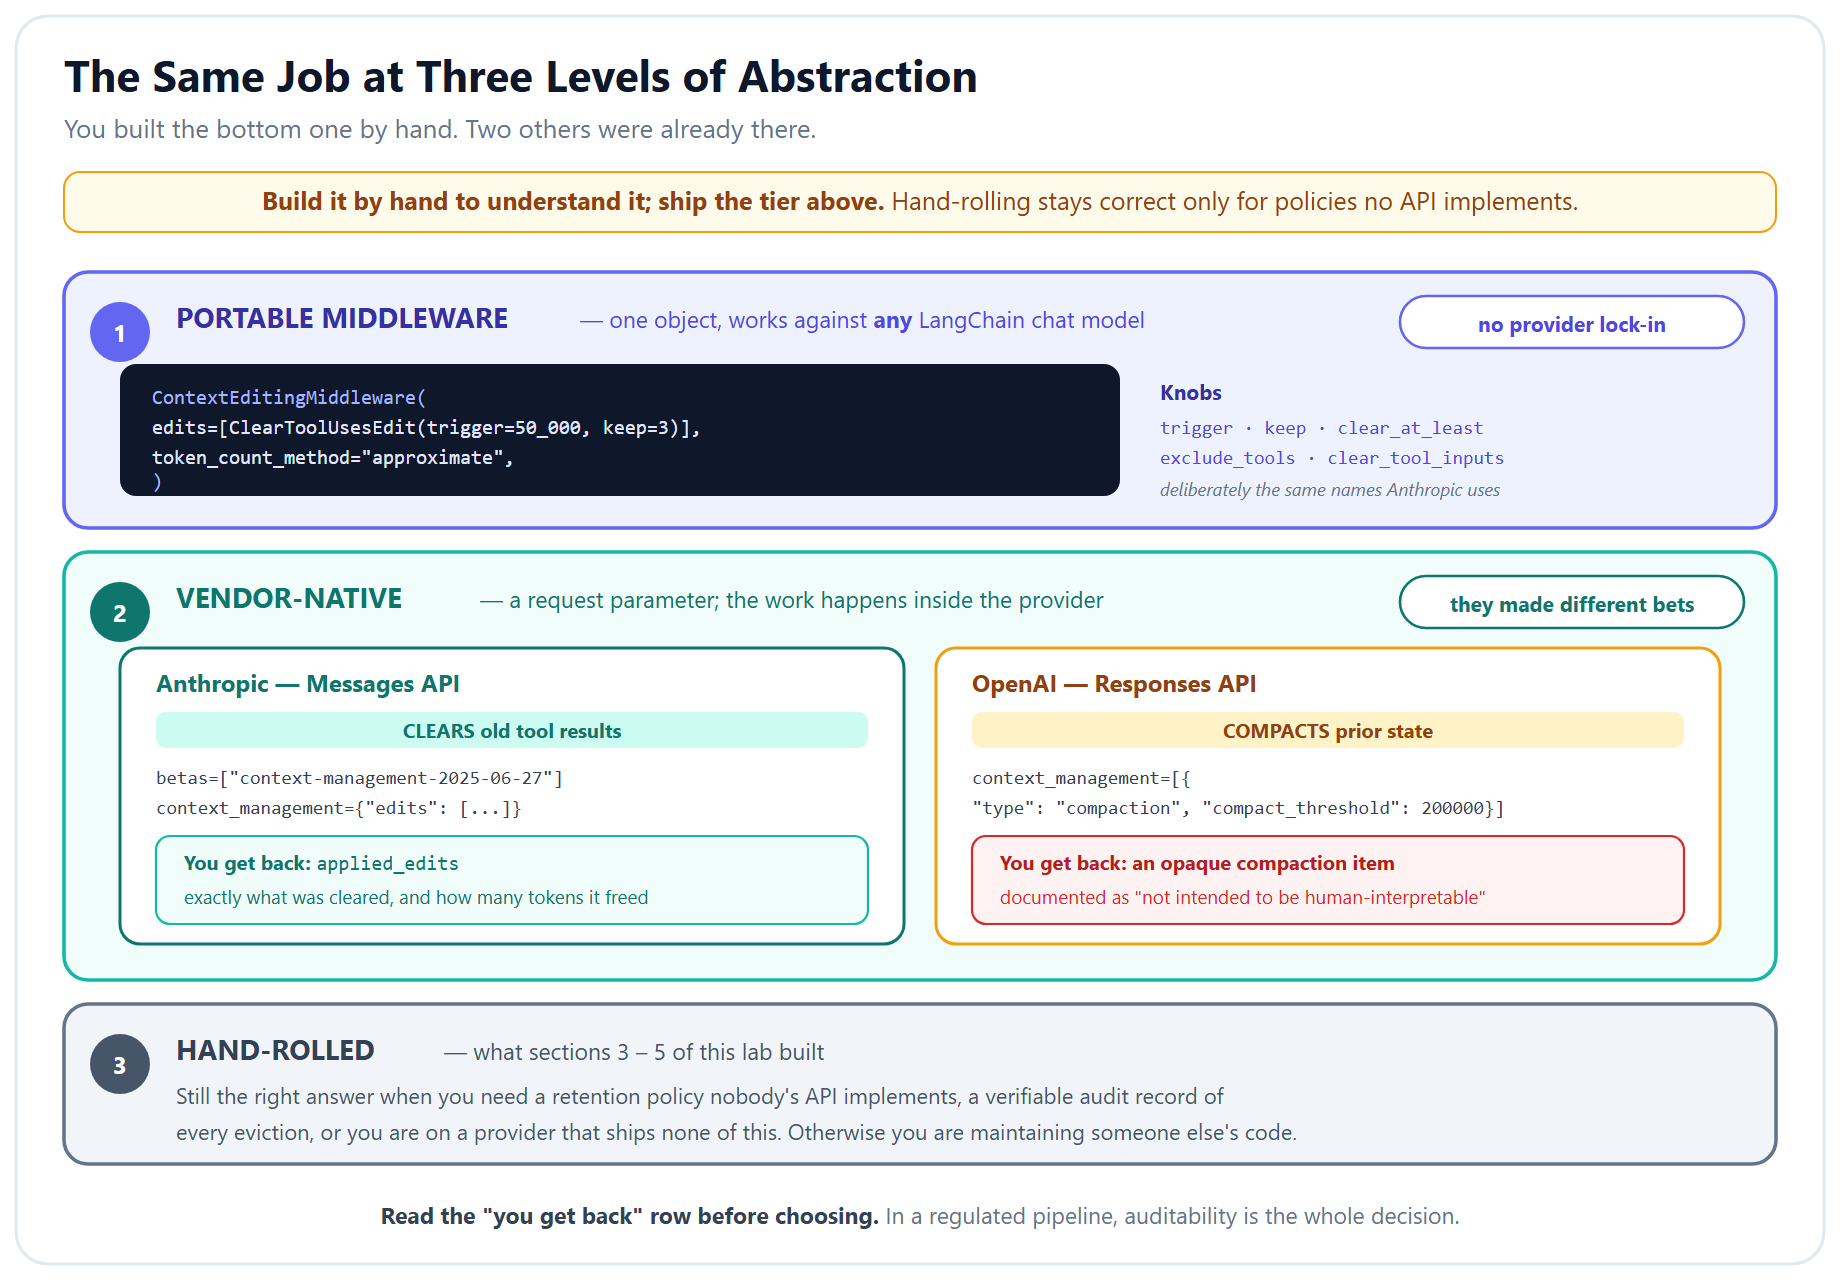

**Figure — The same job at three levels of abstraction.** Sections 3–5 built tier 3 by hand. Tier 1 is one middleware object and runs against any model. Tier 2 is a request parameter and runs inside the provider. Read the row that matters most: Anthropic tells you exactly what it removed and can hand you the compaction block itself; OpenAI compacts and hands back something it documents as not human-interpretable.

In [22]:
# --- Tier 1 in practice: ClearToolUsesEdit, driven directly over a synthetic history ---
# No API calls. `apply()` mutates the message list IN PLACE and returns None.
from langchain_core.messages import ToolMessage
from langchain.agents.middleware.context_editing import (
    ContextEditingMiddleware, ClearToolUsesEdit)


def build_tool_heavy_history(tool_call_count, result_word_count):
    """Build a synthetic ShopSmart history: one customer turn, then N tool-call/result pairs.

    Args:
        tool_call_count: how many order-lookup round-trips to simulate.
        result_word_count: how bulky each tool result should be, in words.

    Returns:
        A list of LangChain messages in valid call/result order.
    """
    messages = [HumanMessage(content="I need updates on all my recent ShopSmart orders.")]
    for index in range(tool_call_count):
        call_identifier = f"call_{index}"
        messages.append(AIMessage(content="", tool_calls=[{
            "name": "lookup_order",
            "args": {"order_id": f"ORD-{1001 + index}"},
            "id": call_identifier,
        }]))
        messages.append(ToolMessage(
            content="order detail " * result_word_count,
            tool_call_id=call_identifier))
    return messages


def approximate_token_counter(messages):
    """Estimate tokens with the four-characters-per-token rule of thumb."""
    return sum(len(str(message.content)) for message in messages) // 4


def summarise_clearing(messages, placeholder="[cleared]"):
    """Return (cleared_count, surviving_count) for the tool results in `messages`."""
    tool_messages = [message for message in messages if isinstance(message, ToolMessage)]
    cleared = sum(1 for message in tool_messages
                  if placeholder in str(message.content))
    return cleared, len(tool_messages) - cleared


reference_history = build_tool_heavy_history(tool_call_count=12, result_word_count=1200)
tool_result_count = sum(1 for message in reference_history
                        if isinstance(message, ToolMessage))
print(f"Synthetic history: {len(reference_history)} messages, "
      f"{approximate_token_counter(reference_history):,} approximate tokens, "
      f"{tool_result_count} tool results\n")

print("=" * 72)
print("The trigger — clearing only fires once the history exceeds it")
print("=" * 72)
for trigger in (5_000, 20_000, 100_000):
    working_history = build_tool_heavy_history(12, 1200)
    ClearToolUsesEdit(trigger=trigger, keep=3).apply(
        working_history, count_tokens=approximate_token_counter)
    cleared, surviving = summarise_clearing(working_history)
    verdict = "cleared" if cleared else "no-op (history is under the trigger)"
    print(f"  trigger={trigger:>7,}  keep=3   ->  {cleared:>2} cleared, "
          f"{surviving:>2} kept   {verdict}")

print("\n" + "=" * 72)
print("keep — how many of the most recent results survive")
print("=" * 72)
for keep in (0, 1, 3, 6, 12):
    working_history = build_tool_heavy_history(12, 1200)
    ClearToolUsesEdit(trigger=5_000, keep=keep).apply(
        working_history, count_tokens=approximate_token_counter)
    cleared, surviving = summarise_clearing(working_history)
    print(f"  keep={keep:<3}                  ->  {cleared:>2} cleared, {surviving:>2} kept")

print("\n" + "=" * 72)
print("⚠️  clear_at_least — NOT what most people expect")
print("=" * 72)
for clear_at_least in (0, 1_000, 50_000):
    working_history = build_tool_heavy_history(12, 1200)
    ClearToolUsesEdit(trigger=5_000, keep=3, clear_at_least=clear_at_least).apply(
        working_history, count_tokens=approximate_token_counter)
    cleared, surviving = summarise_clearing(working_history)
    print(f"  clear_at_least={clear_at_least:>6,}     ->  {cleared:>2} cleared, "
          f"{surviving:>2} kept")
print("\n  Setting it SMALL clears LESS. It is a stop condition, not a floor: the edit clears")
print("  oldest-first until it has freed that many tokens, then stops. 0 disables the guard.")
print("  Set clear_at_least=500 'to be safe' and it looks like the middleware is broken.")

Synthetic history: 25 messages, 46,812 approximate tokens, 12 tool results

The trigger — clearing only fires once the history exceeds it
  trigger=  5,000  keep=3   ->   9 cleared,  3 kept   cleared
  trigger= 20,000  keep=3   ->   9 cleared,  3 kept   cleared
  trigger=100,000  keep=3   ->   0 cleared, 12 kept   no-op (history is under the trigger)

keep — how many of the most recent results survive
  keep=0                    ->  12 cleared,  0 kept
  keep=1                    ->  11 cleared,  1 kept
  keep=3                    ->   9 cleared,  3 kept
  keep=6                    ->   6 cleared,  6 kept
  keep=12                   ->   0 cleared, 12 kept

⚠️  clear_at_least — NOT what most people expect
  clear_at_least=     0     ->   9 cleared,  3 kept
  clear_at_least= 1,000     ->   1 cleared, 11 kept
  clear_at_least=50,000     ->   9 cleared,  3 kept

  Setting it SMALL clears LESS. It is a stop condition, not a floor: the edit clears
  oldest-first until it has freed that many

### 8b. The failure your hand-rolled version has and the middleware does not

There is one bug that breaks naive context trimming in production, it does not show up in short test conversations, and it is worth more than everything else in this section.

**A tool call and its result are a matched pair.** An `AIMessage` carrying `tool_calls` must be followed by a `ToolMessage` answering every `tool_call_id` it names. Drop the `AIMessage` and keep the `ToolMessage` — which is exactly what "keep the last N messages" does at the wrong boundary — and you have produced a `ToolMessage` answering a call that no longer exists.

Every major provider rejects it — and the two ways of breaking the pair give you two *different* errors, which is genuinely useful when you are staring at one in a log. Both quoted exactly as `gpt-4.1-mini` returned them on 2026-08-16:

> **Orphaned result** — the `ToolMessage` survived, its `AIMessage` did not (this is what "keep the last N messages" produces at an odd boundary):
> `Invalid parameter: messages with role 'tool' must be a response to a preceeding message with 'tool_calls'.`
> *(the misspelling of "preceding" is the API's, not ours — it is a handy thing to search your logs for)*

> **Unanswered call** — the `AIMessage` survived, its `ToolMessage` did not (what you get trimming from the other end):
> `An assistant message with 'tool_calls' must be followed by tool messages responding to each 'tool_call_id'. The following tool_call_ids did not have response messages: call_abc123`

It is nasty for three reasons: it depends on *where* the trim boundary lands, so it is intermittent; it only appears once conversations get long enough to trim, which means production and not your tests; and the error talks about message roles and `tool_call_id`s, never about the trimming function that actually caused it.

`ClearToolUsesEdit` sidesteps it entirely by never removing the message. It **keeps the `ToolMessage` in place and replaces only its content** with `[cleared]`. The structure survives; only the payload goes.

The cell below proves both halves — naive trimming breaking the pairing, and the middleware preserving it.

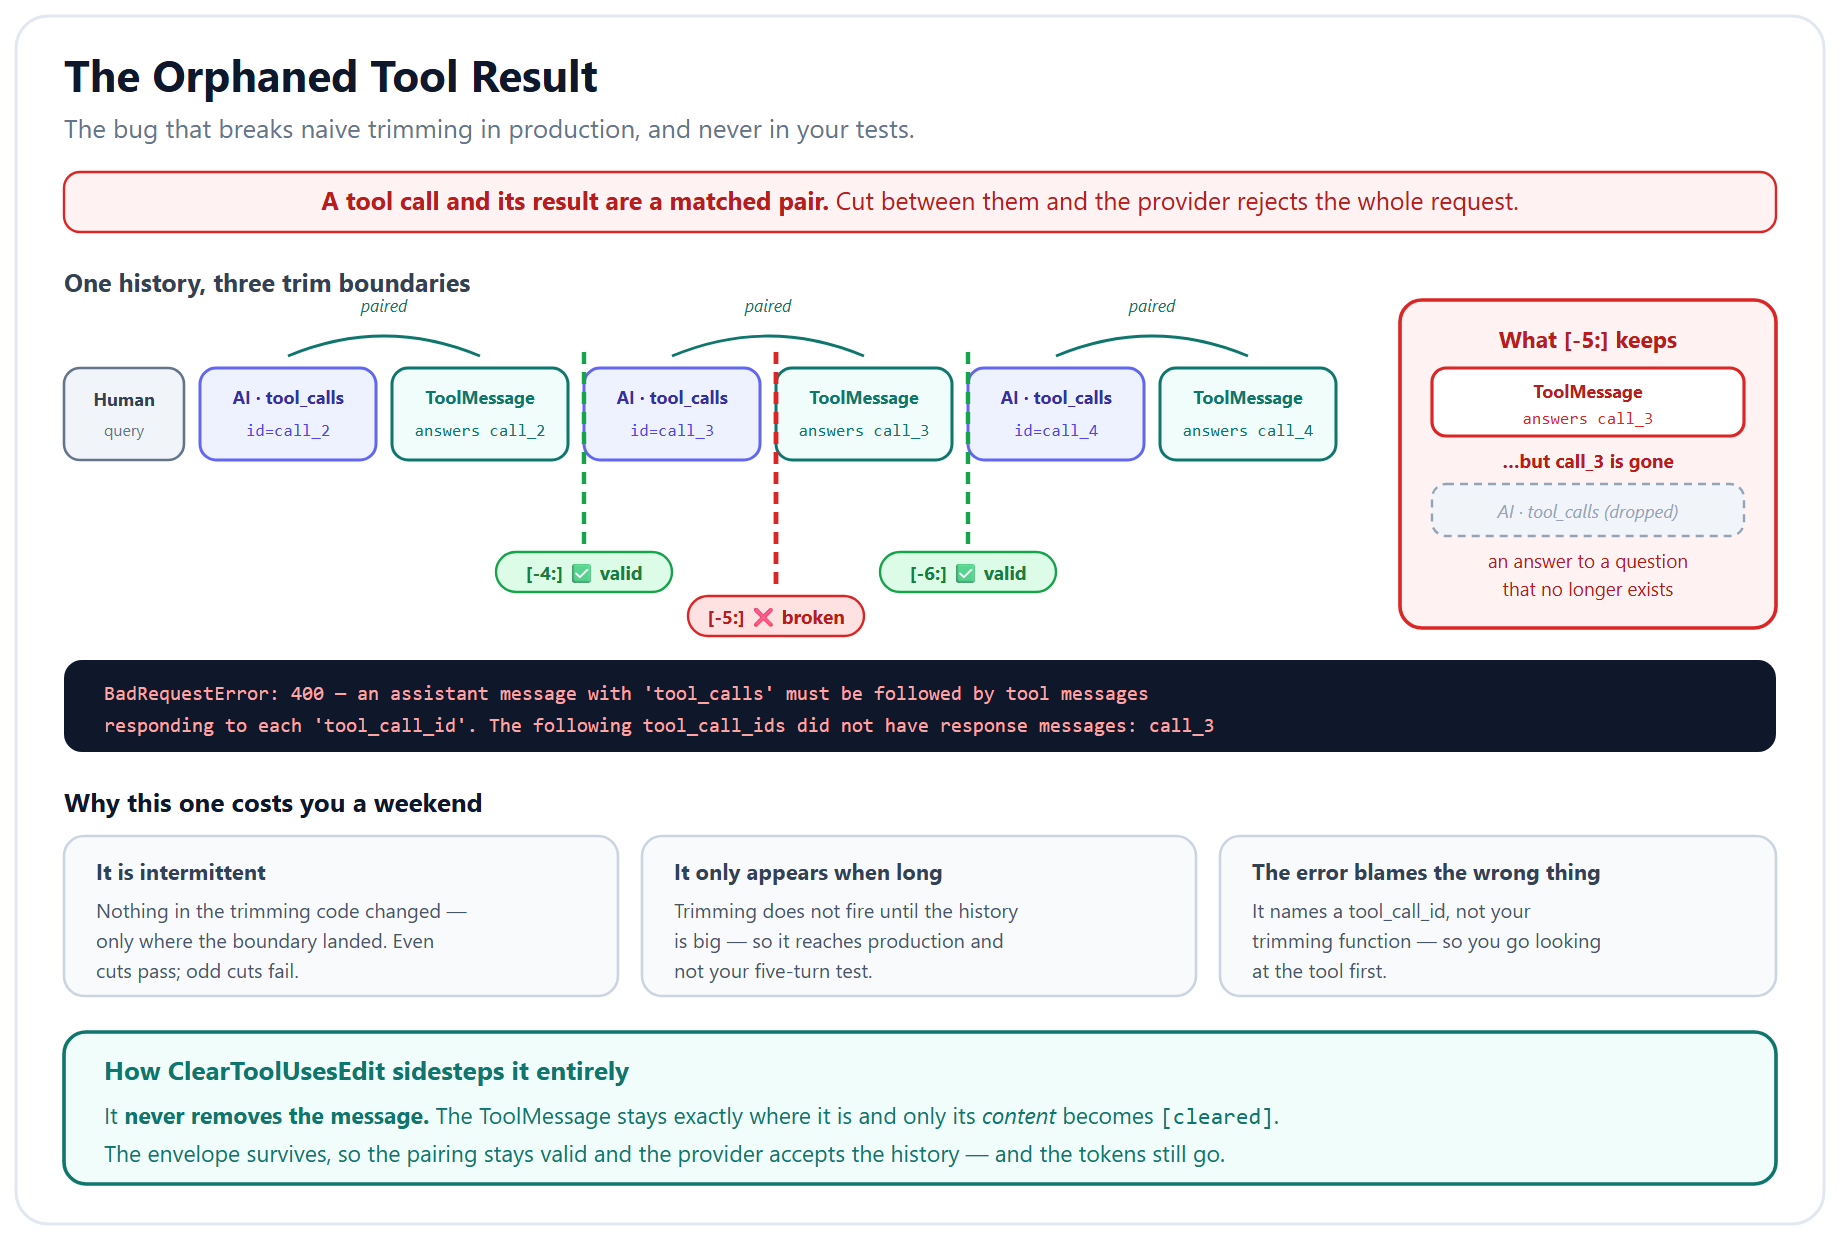

**Figure — Why the trim boundary matters.** A tool call and its result are a matched pair. Cut between them and the surviving `ToolMessage` answers a `tool_call_id` that no longer exists, and every provider rejects the history. `ClearToolUsesEdit` never removes the message — it blanks the content and leaves the envelope — so the structure stays valid while the tokens still go.

In [23]:
# --- The orphaned-tool-result bug, and why the middleware does not have it ---

def check_tool_call_pairing(messages):
    """Report whether every tool call has an answer and every answer has a call.

    Args:
        messages: a list of LangChain messages.

    Returns:
        A dict with the call ids, the answer ids, and the two ways they can disagree.
    """
    call_identifiers = {call["id"]
                        for message in messages if isinstance(message, AIMessage)
                        for call in (message.tool_calls or [])}
    answer_identifiers = {message.tool_call_id
                          for message in messages if isinstance(message, ToolMessage)}
    return {
        "tool_calls": len(call_identifiers),
        "tool_results": len(answer_identifiers),
        "orphaned_results": sorted(answer_identifiers - call_identifiers),
        "unanswered_calls": sorted(call_identifiers - answer_identifiers),
    }


print("=" * 72)
print("NAIVE TRIMMING — 'just keep the last N messages'")
print("=" * 72)
print("The SAME history, trimmed to different lengths. Watch which ones are valid.\n")

naive_history = build_tool_heavy_history(tool_call_count=6, result_word_count=200)
print(f"  full history: {len(naive_history)} messages "
      f"(1 customer turn + 6 tool-call/result pairs)\n")

for keep_last in (4, 5, 6, 7, 8):
    naively_trimmed = naive_history[-keep_last:]
    naive_report = check_tool_call_pairing(naively_trimmed)
    orphaned = naive_report["orphaned_results"]
    verdict = f"❌ REJECTED — orphaned {orphaned}" if orphaned else "✅ valid"
    print(f"  history[-{keep_last}:]  ->  {naive_report['tool_calls']} calls, "
          f"{naive_report['tool_results']} results   {verdict}")

print("\n" + "=" * 72)
print("ClearToolUsesEdit — same history, 9 of 12 results cleared")
print("=" * 72)
middleware_history = build_tool_heavy_history(tool_call_count=12, result_word_count=1200)
ClearToolUsesEdit(trigger=5_000, keep=3).apply(
    middleware_history, count_tokens=approximate_token_counter)
middleware_report = check_tool_call_pairing(middleware_history)
cleared, surviving = summarise_clearing(middleware_history)
print(f"  tool results cleared : {cleared}")
print(f"  tool calls present   : {middleware_report['tool_calls']}")
print(f"  tool results present : {middleware_report['tool_results']}")
print(f"  ORPHANED results     : {middleware_report['orphaned_results'] or 'none'}")
print(f"  unanswered calls     : {middleware_report['unanswered_calls'] or 'none'}")

first_tool_result = next(str(message.content) for message in middleware_history
                         if isinstance(message, ToolMessage))
print(f"\n  what a cleared result now contains: {first_tool_result!r}")
print("\n  ✅ The ToolMessage stayed. Only its content went. The pairing is still valid,")
print("     so the provider accepts the history — and you still freed the tokens.")

NAIVE TRIMMING — 'just keep the last N messages'
The SAME history, trimmed to different lengths. Watch which ones are valid.

  full history: 13 messages (1 customer turn + 6 tool-call/result pairs)

  history[-4:]  ->  2 calls, 2 results   ✅ valid
  history[-5:]  ->  2 calls, 3 results   ❌ REJECTED — orphaned ['call_3']
  history[-6:]  ->  3 calls, 3 results   ✅ valid
  history[-7:]  ->  3 calls, 4 results   ❌ REJECTED — orphaned ['call_2']
  history[-8:]  ->  4 calls, 4 results   ✅ valid

ClearToolUsesEdit — same history, 9 of 12 results cleared
  tool results cleared : 9
  tool calls present   : 12
  tool results present : 12
  ORPHANED results     : none
  unanswered calls     : none

  what a cleared result now contains: '[cleared]'

  ✅ The ToolMessage stayed. Only its content went. The pairing is still valid,
     so the provider accepts the history — and you still freed the tokens.


### 8c. One more thing before you turn this on: compaction fights your prompt cache

Prompt caching works on a **stable prefix**. The provider hashes the front of your prompt and reuses the computation when the next request starts identically.

Clearing or compacting rewrites the middle of the conversation, which invalidates every cached prefix from the edit point onward. So an aggressive policy can *cost* you money:

> Clear 500 tokens of stale tool output → invalidate a 40,000-token cached prefix → pay full price to re-process all 40,000 next turn.

That is exactly what `clear_at_least` exists for. Anthropic documents it as the minimum number of tokens to clear, so that **cache invalidation is worth doing at all**. It is not a safety knob — it is an economics knob. Set it high enough that the tokens you free exceed the cache you destroy.

This also explains the design of Fix 3 in section 5. The JIT system prompt puts the stable material first and the varying policy section last, precisely so the cacheable prefix survives every turn. Context engineering and caching are the same problem viewed from two directions.

## 9. Deep dive — counting tokens is provider-specific

*Self-paced.*

Every budget in this lab was computed with one line:

```python
encoding = tiktoken.encoding_for_model("gpt-4o")
```

`tiktoken` is **OpenAI's** tokenizer. Used against an OpenAI model it is exact. Used to budget an Anthropic or Gemini context window it is an estimate — and the direction of the error is not guaranteed.

Three things follow, and all three bite in production:

1. **Count with the provider's own counter for the provider you are calling.** Anthropic exposes a token-counting endpoint; `ChatAnthropic.get_num_tokens_from_messages` calls it. Note a sharp edge worth knowing: because it hits the real API, it **errors on an invalid message sequence** — an orphaned tool result from section 8b will surface here as a token-counting failure rather than as the pairing error it actually is.

2. **Message overhead is real and undocumented.** This lab adds `+4` tokens per message as a rule of thumb. Providers add their own framing around roles, names and tool schemas. Your count is always a little low.

3. **Leave headroom.** A budget computed to the last token will overflow the moment a tool returns more than you expected. The 128K budget in section 6 reserves a safety margin for exactly this reason — and that margin is the first thing people delete when they want more room, which is how you get a context-overflow incident.

`ContextEditingMiddleware` gives you the choice explicitly:

```python
ContextEditingMiddleware(
    edits=[ClearToolUsesEdit(trigger=50_000, keep=3)],
    token_count_method="approximate",   # fast, local, and an estimate
    # token_count_method="model",       # asks the model; accurate, costs a round-trip
)
```

`"approximate"` is the default. It is the right default for a trigger, because a trigger only needs to be roughly right — but if you are enforcing a hard budget rather than a soft threshold, be aware which one you are relying on.

## 10. Deep dive — context management is not memory

*Self-paced.*

These two get conflated constantly, and the distinction decides which tool you reach for:

| | **Context management** | **Memory** |
|---|---|---|
| Question | What is in *this request's* window? | What survives across *sessions*? |
| Lifetime | One request | Indefinite |
| Techniques | Trim, summarise, clear, compact | Store, index, retrieve, consolidate |
| Where it lives | This lab | Lab 7.2 (checkpoints), and below |

Everything in sections 1–9 is the left column. This is a map of the right one.

### The default: stay in core

| Layer | Use | Why |
|---|---|---|
| **Context management** | `SummarizationMiddleware`, `ContextEditingMiddleware` | In `langchain` core, model-agnostic, no extra dependency, no extra service |
| **Long-term memory** | LangGraph `BaseStore` → `InMemoryStore`, `PostgresStore` | In `langgraph` core. Namespaced like folder paths, with semantic search in the open-source stores |

Both are part of the framework you already have. Neither will be orphaned by the next refactor.

### The specialist options, and when each earns its place

| Option | Status (checked Aug 2026) | Choose it when |
|---|---|---|
| **Zep / Graphiti** | Temporal knowledge graph — facts are edges with **validity windows**. Best measured accuracy of the group: 63.8% on LongMemEval vs Mem0's 49.0% | Facts change over time and you must know *when* something was true. Most regulated domains. |
| **Mem0** | 2.0.18, Apache-2.0, ~48K stars. Local library, self-hosted Docker, or managed cloud. Scopes memory conversation → session → user → org and promotes facts upward | You want an accumulating user profile with the least ceremony |
| **Letta** (ex-MemGPT) | An agent *runtime* where the agent edits its own working memory, OS-style RAM/disk | Memory management should be the agent's job, not yours. A different architecture, not a library |
| **LangMem** | ⚠️ **Not deprecated, but quiet.** Latest release 0.0.30, October 2025 — no release in ~10 months. Repo still active, docs still point at it | You are on LangGraph and refuse to add a service — with the staleness understood |

> **On LangMem specifically.** The pattern is familiar: `langgraph-supervisor` is also 0.0.x and also quiet, and teams often hand-build a supervisor rather than depend on it. LangMem has the same profile — pre-1.0, slow release cadence, satellite package. Its *ideas* (memory extraction, background consolidation, procedural memory) are worth knowing. Taking the dependency is a different decision.

**The pattern to notice:** in both columns the safest choice is the one that lives in the core package. Satellite packages solve a real problem and then go quiet, and a lab that depends on one dates the moment it does.

## 11. From lab to production

*Self-paced.*

The three fixes work. Here is what stands between them and something you can put behind an endpoint — each item is either yours to add today, or something your production stack will need to own.

*Several of the rows below are the same problem in different clothes — cost accounting, structured failure records, versioned configuration, dataset versioning. Teams running more than one agent usually end up factoring those into a shared internal library rather than rebuilding them per service. This programme does not ship one; being able to name what would belong in it is the point.*

| Gap in this notebook | What production needs | Where it lands |
|---|---|---|
| Compaction is hand-rolled | `ContextEditingMiddleware` / `SummarizationMiddleware`, configured — not rewritten | You, today (section 8) |
| Trimming can orphan a tool result | Pairing repair on every trim, and a test that catches it | Your production stack |
| One tokenizer for all providers | Provider-aware counting, with the estimate labelled as one | Your production stack |
| Compaction ignores the prompt cache | Cache-boundary awareness, so an edit never costs more than it saves | Your production stack |
| Compaction events are invisible | Telemetry per event: what was cleared, how many tokens, at what turn | Your production stack |
| The summariser can drop a decision | Retention rules with a verifiable audit record of every eviction | Your production stack |
| Quality is scored every 5th turn, by hand | A regression suite that gates the change | Your production stack |
| History lives in a Python list | A checkpointer — `PostgresSaver`, so a restart does not lose the conversation | Lab 7.2 shows the pattern; your production stack runs it |

**If you take one thing from this lab:** the fix is not "use less context", it is **decide what earns its place in the window, and measure what that decision cost you**. Sections 2 and 7 are the load-bearing parts — the problem measured, and the fixes measured against it. Everything in between is technique.

## Conclusion

We gave ShopSmart's support agent real tools, ran it for 30 turns, and applied three context
engineering techniques — measuring what each one saved and what each one cost.

1. **History compaction** — summarise the old turns. The largest single reduction of the three,
   and the only fix that spends a model call to do its job, so its saving has to be quoted net of
   the summariser's own tokens. It is also the only one that rewrites the *customer's* words
   rather than a tool's output, which is why it is the one that dropped a fact.
2. **Tool-result clearing** — blank the payloads the agent has already read, keep the messages.
   Cost nothing extra and lost nothing: it only ever
   discards JSON, never anything the customer said.
3. **JIT policy retrieval** — load the one policy section the turn needs, and nothing at all
   when the turn needs no policy. A steady saving on every single turn, with the stable
   prefix left intact for the cache.

**The result worth carrying out of this lab is the trade, not the total.** Read your dashboard
again: adding the fixes that touch only tool output lost no further planted facts, and the
summariser is what dropped them — most of all when it ran on every turn. *What* you drop matters more than *how much* you drop — and
when you drop it (a trigger, not every turn) decides how often you have to drop anything at all.

**And the honest scale.** Nothing here came close to filling a 128K window. At this size the
pressure is the invoice: the baseline's per-conversation cost, multiplied by your daily
conversation volume, is the number that justifies any of this work. Context *limits* start to
bite where section 8 picks the story up — agentic runs where a dozen tool calls make about 47,000
tokens an ordinary afternoon.

### Next Lab Preview
In the **Reusable Skills & Prompt Optimization** take-home we build **reusable skill packs** the agent loads on demand — via a tool call and via a dynamic system prompt — then A/B test them against a generic agent with the same cross-family LLM-as-Judge you used here. Skills turn out to be the *other half* of this lab: context management decides what leaves the window, skills decide what is allowed in.

## Further reading

**Start here — the two that shaped this lab**
- [Effective context engineering for AI agents](https://www.anthropic.com/engineering/effective-context-engineering-for-ai-agents) — Anthropic. The four-pillar framing (system prompt, budgeting, retrieval, compaction) this lab follows.
- [Context editing](https://platform.claude.com/docs/en/build-with-claude/context-editing) — the server-side API from section 8, with every parameter documented.

**The APIs you met in section 8**
- [LangChain `context_editing` middleware](https://reference.langchain.com/python/langchain/agents/middleware/context_editing) — `ContextEditingMiddleware`, `ClearToolUsesEdit`.
- [LangChain prebuilt middleware](https://docs.langchain.com/oss/python/langchain/middleware/built-in) — the full list, including `SummarizationMiddleware`.
- [OpenAI compaction guide](https://developers.openai.com/api/docs/guides/compaction) — `context_management` + `compact_threshold`.
- [OpenAI conversation state](https://developers.openai.com/api/docs/guides/conversation-state) — `previous_response_id`, the Conversations API, `store`.
- [OpenAI Agents SDK context](https://openai.github.io/openai-agents-python/context/) — the session abstractions from section 7.

**Going further**
- [Context management for deep agents](https://www.langchain.com/blog/context-management-for-deepagents) — LangChain.
- [LangGraph persistence](https://docs.langchain.com/oss/python/langgraph/persistence) — checkpointers and the `BaseStore` from section 10.